<a href="https://colab.research.google.com/github/BogdanT54/data-viz/blob/main/Proiect_Vizualizarea_Datelor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Analiza Macroeconomică a României în Context European (2000–2026)
### Disciplina: Vizualizarea Datelor
---
**Autor:** *[Numele tău]*  
**An universitar:** 2024–2025  

> *"România a crescut economic spectaculos în 25 de ani, dar această creștere este fragilă, inegală și demografic nesustenabilă."*


---
## 📌 PUNCTUL 1 - Semnificația temei, organizarea, relevanța și coerența datelor *(1.5p)*

### 1.1 Motivația alegerii temei

România a parcurs în ultimii 25 de ani una dintre cele mai spectaculoase transformări economice din Europa Centrală și de Est: de la o economie cu inflație de **45% în 2001** la una cu inflație sub 5% în 2024, de la un PIB/cap de **~$1.600** la peste **$20.000**. Această temă este relevantă din multiple perspective:

- **Istorică:** surprinde traiectoria de la tranziția post-comunistă la statutul de stat UE și convergența europeană
- **Financiară:** evidențiază stabilitatea monetară (EUR/RON), politica BNR, piața de capital și sustenabilitatea fiscală
- **Demografică:** radiografiază bomba cu ceas demografică - îmbătrânire + emigrație - care amenință tot restul

### 1.2 Structura narativă: 4 acte

| Act | Perioadă | Tema centrală |
|-----|----------|---------------|
| **I**   | 2000–2007 | Tranziția și pregătirea pentru UE - inflație mare, creștere rapidă |
| **II**  | 2007–2012 | Aderare UE, boom și criză financiară globală |
| **III** | 2012–2021 | Consolidare cu vulnerabilități - deficit, deficit, deficit |
| **IV**  | 2021–2026 | Inflație record, presiune demografică, piață de capital în expansiune |

### 1.3 Seturile de date utilizate

| Nr. | Fișier CSV | Conținut | Frecvență | Perioadă | Sursă |
|-----|-----------|----------|-----------|----------|-------|
| 1 | `pib_nominal_anual.csv` | PIB nominal USD, creștere %, PIB/cap | Anuală | 2000–2025 | World Bank |
| 2 | `pib_trimestrial.csv` | Indice volum PIB RO + Euro Area (2020=100) | Trimestrială | 2000–2026 | Eurostat |
| 3 | `ipc_lunar.csv` | IPC lunar față de luna anterioară (%) | Lunară | 2000–2026 | INS |
| 4 | `inflatie_anuala.csv` | Rata inflației anuale (%) | Anuală | 2000–2025 | INS |
| 5 | `dobanzi_bnr.csv` | Dobânda de politică monetară BNR (%) | Lunară | 2003–2026 | BNR |
| 6 | `hicp_lunar.csv` | HICP lunar RO și UE-27 (%) | Lunară | 2000–2025 | Eurostat |
| 7 | `curs_valutar.csv` | EUR/RON, EUR/PLN, EUR/HUF zilnic + indici | Zilnică | 2005–2026 | ECB / BNR |
| 8 | `somaj_trimestrial.csv` | Rata șomajului BIM pe trimestre (%) | Trimestrială | 2000–2026 | INS |
| 9 | `salariu_minim.csv` | Salariul minim brut/net (RON) | La modificare | 2005–2026 | Legislație |
| 10 | `castig_salarial_total.csv` | Câștigul salarial mediu net lunar (RON) | Lunară | 2000–2025 | INS |
| 11 | `deficit_bugetar.csv` | Deficit bugetar RO și UE (% PIB) | Anuală | 2000–2025 | Eurostat |
| 12 | `datorie_publica.csv` | Datorie publică RO și UE (% PIB) | Anuală | 2000–2025 | Eurostat |
| 13 | `randament_10y.csv` | Randament obligațiuni stat 10Y RO și UE | Lunară | 2005–2026 | Eurostat |
| 14 | `rezerve_bnr.csv` | Rezerve internaționale totale BNR (mil. EUR) | Lunară | 2005–2026 | BNR |
| 15 | `bet_zilnic.csv` | Indicele BET - prețuri zilnice (puncte) | Zilnică | 2010–2026 | BVB |
| 16 | `capitalizare_bvb.csv` | Capitalizare bursieră BVB (mld. RON) | Anuală | 2000–2026 | BVB |
| 17 | `pmi_lunar.csv` | PMI Manufacturing Eurozonă | Lunară | 2005–2025 | S&P Global |
| 18 | `natalitate.csv` | Rata natalității (‰) | Anuală | 2000–2024 | INS |
| 19 | `populatie_grupe_varsta.csv` | Populație pe grupe de vârstă și sex | Anuală | 2003–2025 | INS |
| 20 | `emigranti.csv` | Emigranți definitivi (nr. persoane) | Anuală | 2000–2024 | INS |
| 21 | `migratie_neta.csv` | Migrație netă anuală (nr. persoane) | Anuală | 2000–2024 | Eurostat |

### 1.4 Organizarea notebook-ului

Notebook-ul urmează o structură **tematică** cu 7 capitole analitice + 1 dashboard interactiv, totalizând **15 grafice**. Toate datele sunt reale, descărcate din surse oficiale (INS, BNR, Eurostat, BVB, ECB) și pre-procesate în format CSV uniform.

> **⚠️ Notă:** Plasați toate fișierele CSV în același director cu notebook-ul înainte de rulare.


---
## ⚙️ Setup - Biblioteci și Configurare Globală


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import ipywidgets as pyw
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

print("✓ Biblioteci importate cu succes.")

✓ Biblioteci importate cu succes.


In [8]:
# ── Culori globale ──────────────────────────────────────────────
CUL = {
    'ro':      '#CC0000',
    'ue':      '#003399',
    'ea':      '#0066CC',
    'pln':     '#003087',
    'huf':     '#477050',
    'verde':   '#2E7D32',
    'rosu':    '#CC0000',
    'gri':     '#757575',
    'galben':  '#F9A825',
    'portoc':  '#E67E22',
}

# ── Ere istorice (pentru axele X anuale) ────────────────────────
ERE = [
    (2000, 2004, '#FFF3E0', 'Pre-UE'),
    (2004, 2007, '#E8F5E9', 'Negocieri'),
    (2007, 2009, '#E3F2FD', 'Post-aderare'),
    (2009, 2012, '#FFEBEE', 'Criză'),
    (2012, 2020, '#F3E5F5', 'Consolidare'),
    (2020, 2026, '#FFF8E1', 'Post-pandemic'),
]

FIGSIZE_W  = (18, 6)   # wide
FIGSIZE_SQ = (16, 7)   # standard

def adauga_ere(ax, ere=ERE, ymin=None, ymax=None):
    ylim = ax.get_ylim()
    y0 = ymin if ymin else ylim[0]
    y1 = ymax if ymax else ylim[1]
    for start, end, culoare, label in ere:
        ax.axvspan(start, end, alpha=0.25, color=culoare, zorder=0)
        ax.text((start+end)/2, y1, label, ha='center', va='top',
                fontsize=6.5, color='#555555', style='italic')

print("✓ Constante și funcții globale definite.")

✓ Constante și funcții globale definite.


---
## 📌 PUNCTUL 2 - Procesarea datelor în vederea vizualizării *(2p)*

Toate fișierele sunt în format CSV uniform - `pd.read_csv()` direct, fără procesare suplimentară. Coloanele de dată sunt parsate explicit, valorile numerice sunt verificate pentru NaN.


In [51]:
# ── PIB ─────────────────────────────────────────────────────────
df_pib_nom = pd.read_csv('pib_nominal_anual.csv')
df_pib_nom = df_pib_nom.sort_values('an').reset_index(drop=True)

df_pib_trim = pd.read_csv('pib_trimestrial.csv')
df_pib_trim['data'] = pd.to_datetime(df_pib_trim['an'].astype(str) + '-' +
    df_pib_trim['q'].map({'Q1':'01','Q2':'04','Q3':'07','Q4':'10'}))
df_pib_trim = df_pib_trim.sort_values('data').reset_index(drop=True)

# Calculăm variația trimestrială față de același trimestru al anului anterior
df_pib_trim['crestere_ro_yoy'] = df_pib_trim['pib_romania_idx'].pct_change(4) * 100
df_pib_trim['crestere_ea_yoy'] = df_pib_trim['pib_euroarea_idx'].pct_change(4) * 100

print(f"✓ PIB nominal: {df_pib_nom.shape[0]} ani | PIB trimestrial: {df_pib_trim.shape[0]} trimestre")
print(f"  PIB nominal 2024: ${df_pib_nom[df_pib_nom['an']==2024]['pib_nominal_usd'].values[0]/1e9:.1f} mld USD")
print(f"  PIB trimestrial: {df_pib_trim['trimestru'].iloc[0]} → {df_pib_trim['trimestru'].iloc[-1]}")

✓ PIB nominal: 26 ani | PIB trimestrial: 105 trimestre
  PIB nominal 2024: $382.9 mld USD
  PIB trimestrial: 2000-Q1 → 2026-Q1


In [52]:
# ── Inflație & BNR ──────────────────────────────────────────────
df_ipc = pd.read_csv('ipc_lunar.csv', parse_dates=['data'])
df_inflatie = pd.read_csv('inflatie_anuala.csv')
df_inflatie = df_inflatie[df_inflatie['an'] >= 2000].reset_index(drop=True)

df_bnr = pd.read_csv('dobanzi_bnr.csv', parse_dates=['data'])
df_bnr = df_bnr.sort_values('data').reset_index(drop=True)

df_hicp = pd.read_csv('hicp_lunar.csv', parse_dates=['data'])
df_hicp = df_hicp.sort_values('data').reset_index(drop=True)

# Merge IPC + BNR pe an-lună pentru graficul dual-axis
df_ipc['an']  = df_ipc['data'].dt.year
df_ipc['luna'] = df_ipc['data'].dt.month
df_bnr['an']  = df_bnr['data'].dt.year
df_bnr['luna'] = df_bnr['data'].dt.month
df_inf_merged = df_ipc.merge(df_bnr[['an','luna','dobanda_pm']], on=['an','luna'], how='left')

print(f"✓ IPC lunar: {df_ipc.shape[0]} luni | BNR dobânzi: {df_bnr.shape[0]} luni | HICP: {df_hicp.shape[0]} luni")
print(f"  Inflație maximă (anual): {df_inflatie['rata_inflatie_pct'].max():.1f}% în {int(df_inflatie.loc[df_inflatie['rata_inflatie_pct'].idxmax(),'an'])}")
print(f"  Dobândă BNR curentă: {df_bnr['dobanda_pm'].iloc[-1]:.2f}%")

✓ IPC lunar: 315 luni | BNR dobânzi: 280 luni | HICP: 312 luni
  Inflație maximă (anual): 45.7% în 2000
  Dobândă BNR curentă: 6.50%


In [53]:
# ── Curs Valutar ────────────────────────────────────────────────
df_curs = pd.read_csv('curs_valutar.csv', parse_dates=['data'])
df_curs = df_curs.sort_values('data').reset_index(drop=True)

# Versiune lunară (medie) pentru grafice mai clare
df_curs['an']  = df_curs['data'].dt.year
df_curs['luna'] = df_curs['data'].dt.month
df_curs_lunar = df_curs.groupby(['an','luna'])[['eur_ron','eur_pln','eur_huf','ron_idx','pln_idx','huf_idx']].mean().reset_index()
df_curs_lunar['data'] = pd.to_datetime(df_curs_lunar['an'].astype(str) + '-' + df_curs_lunar['luna'].astype(str).str.zfill(2))

print(f"✓ Curs valutar zilnic: {df_curs.shape[0]} zile | Lunar: {df_curs_lunar.shape[0]} luni")
print(f"  EUR/RON: {df_curs['eur_ron'].iloc[0]:.4f} (2005-07) → {df_curs['eur_ron'].iloc[-1]:.4f} (2026)")
print(f"  Variație EUR/RON: {((df_curs['eur_ron'].iloc[-1]/df_curs['eur_ron'].iloc[0])-1)*100:+.1f}% față de baza 2005")

✓ Curs valutar zilnic: 5342 zile | Lunar: 251 luni
  EUR/RON: 3.6030 (2005-07) → 5.2166 (2026)
  Variație EUR/RON: +44.8% față de baza 2005


In [54]:
# ── Piața Muncii ────────────────────────────────────────────────
df_somaj_trim = pd.read_csv('somaj_trimestrial.csv')
df_somaj_trim['data'] = pd.to_datetime(
    df_somaj_trim['an'].astype(str) + '-' +
    df_somaj_trim['trimestru'].map({1:'01',2:'04',3:'07',4:'10'}))
df_somaj_trim = df_somaj_trim.sort_values('data').reset_index(drop=True)

df_somaj_an = pd.read_csv('somaj_anual.csv')

df_sal_min = pd.read_csv('salariu_minim.csv')
df_sal_min = df_sal_min.sort_values(['an','luna']).reset_index(drop=True)
df_sal_min['data'] = pd.to_datetime(df_sal_min['an'].astype(str) + '-' + df_sal_min['luna'].astype(str).str.zfill(2))

df_castig = pd.read_csv('castig_salarial_total.csv')
df_castig['data'] = pd.to_datetime(df_castig['an'].astype(str) + '-' + df_castig['luna'].astype(str).str.zfill(2))
df_castig = df_castig.sort_values('data').reset_index(drop=True)

print(f"✓ Șomaj trimestrial: {df_somaj_trim.shape[0]} | Salariu minim: {df_sal_min.shape[0]} modificări")
print(f"  Câștig salarial: {df_castig.shape[0]} luni | {df_castig['data'].iloc[0].strftime('%Y-%m')} → {df_castig['data'].iloc[-1].strftime('%Y-%m')}")
print(f"  Câștig net mediu: {df_castig['castig_net_total_ron'].iloc[-1]:.0f} RON (ultima lună)")

✓ Șomaj trimestrial: 104 | Salariu minim: 21 modificări
  Câștig salarial: 312 luni | 2000-01 → 2025-12
  Câștig net mediu: 5914 RON (ultima lună)


In [55]:
# ── Finanțe Publice ─────────────────────────────────────────────
df_deficit = pd.read_csv('deficit_bugetar.csv')
df_datorie = pd.read_csv('datorie_publica.csv')
df_rand = pd.read_csv('randament_10y.csv', parse_dates=['data'])
df_rand = df_rand.sort_values('data').reset_index(drop=True)
df_rezerve = pd.read_csv('rezerve_bnr.csv', parse_dates=['data'])
df_rezerve = df_rezerve.sort_values('data').reset_index(drop=True)
df_rezerve['rezerve_mld_eur'] = df_rezerve['rezerve_total_mil_eur'] / 1000

# Merge randament + rezerve pe an-lună
df_rand['an']  = df_rand['data'].dt.year
df_rand['luna'] = df_rand['data'].dt.month
df_rezerve['an']  = df_rezerve['data'].dt.year
df_rezerve['luna'] = df_rezerve['data'].dt.month
df_rand_rez = df_rand.merge(df_rezerve[['an','luna','rezerve_mld_eur']], on=['an','luna'], how='left')

print(f"✓ Deficit: {df_deficit.shape[0]} ani | Datorie: {df_datorie.shape[0]} ani | Randament 10Y: {df_rand.shape[0]} luni")
print(f"  Deficit RO 2024: {df_deficit[df_deficit['an']==2024]['deficit_ro_pct'].values[0]}% PIB")
print(f"  Datorie RO 2024: {df_datorie[df_datorie['an']==2024]['datorie_ro_pct'].values[0]}% PIB")
print(f"  Rezerve BNR actuale: {df_rezerve['rezerve_mld_eur'].iloc[-1]:.1f} mld EUR")

✓ Deficit: 26 ani | Datorie: 26 ani | Randament 10Y: 316 luni
  Deficit RO 2024: -9.3% PIB
  Datorie RO 2024: 54.8% PIB
  Rezerve BNR actuale: 78.0 mld EUR


In [56]:
# ── Piața de Capital & PMI ───────────────────────────────────────
df_bet = pd.read_csv('bet_zilnic.csv', parse_dates=['data'])
df_bet = df_bet.sort_values('data').reset_index(drop=True)
df_bet_lunar = df_bet.set_index('data').resample('ME')['bet_pret'].mean().reset_index()

df_bvb = pd.read_csv('capitalizare_bvb.csv')
df_bvb = df_bvb.sort_values('an').reset_index(drop=True)

df_pmi = pd.read_csv('pmi_lunar.csv', parse_dates=['data'])
df_pmi = df_pmi.sort_values('data').dropna().reset_index(drop=True)
df_pmi['an'] = df_pmi['data'].dt.year
df_pmi_an = df_pmi.groupby('an')['pmi_eurozona'].mean().reset_index()

# Merge BVB + PMI anual
df_bvb_pmi = df_bvb.merge(df_pmi_an, on='an', how='left')

print(f"✓ BET zilnic: {df_bet.shape[0]} zile | Capitalizare BVB: {df_bvb.shape[0]} ani | PMI: {df_pmi.shape[0]} luni")
print(f"  BET: {df_bet['bet_pret'].iloc[0]:.0f} (mai 2010) → {df_bet['bet_pret'].iloc[-1]:.0f} puncte (mai 2026)")
print(f"  Cap. BVB 2024: {df_bvb[df_bvb['an']==2024]['capitalizare_mld_ron'].values[0]:.1f} mld RON")

✓ BET zilnic: 4006 zile | Capitalizare BVB: 27 ani | PMI: 245 luni
  BET: 4979 (mai 2010) → 30497 puncte (mai 2026)
  Cap. BVB 2024: 350.3 mld RON


In [57]:
# ── Demografie ──────────────────────────────────────────────────
df_natal = pd.read_csv('natalitate.csv')
df_pop   = pd.read_csv('populatie_grupe_varsta.csv')
df_emig  = pd.read_csv('emigranti.csv')
df_mig   = pd.read_csv('migratie_neta.csv')

# Merge demografie anuală
df_demo = df_natal.merge(df_mig, on='an', how='outer').merge(df_emig, on='an', how='outer')
df_demo = df_demo.sort_values('an').reset_index(drop=True)
df_demo['emigranti_mii'] = df_demo['emigranti_nr'] / 1000

# Piramida: date pentru 2003 și 2024
ani_piramida = [2003, 2024]
ORDINE_GRUPE = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
                '40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80-84','85sipeste']

print(f"✓ Natalitate: {df_natal.shape[0]} ani | Populație grupe: {df_pop.shape[0]} rânduri")
print(f"  Ani disponibili pentru piramidă: {sorted(df_pop['an'].unique())[:3]}...{sorted(df_pop['an'].unique())[-1]}")
print(f"  Grupe de vârstă: {df_pop['grupa_varsta'].nunique()} grupe")
print(f"  Emigranți 2007: {df_emig[df_emig['an']==2007]['emigranti_nr'].values[0]:,} persoane")

✓ Natalitate: 25 ani | Populație grupe: 828 rânduri
  Ani disponibili pentru piramidă: [np.int64(2003), np.int64(2004), np.int64(2005)]...2025
  Grupe de vârstă: 18 grupe
  Emigranți 2007: 8,830 persoane


---
## 📌 PUNCTUL 3 - Tipuri de diagrame și vizualizări *(2p)*

| # | Grafic | Capitol | Tip vizualizare | Date |
|---|--------|---------|-----------------|------|
| G1.1 | PIB nominal anual | PIB | Bare colorate (verde/roșu) | `pib_nominal_anual.csv` |
| G1.2 | PIB trimestrial RO vs Euro Area | PIB | Linie multi-serie | `pib_trimestrial.csv` |
| G2.1 | Inflație IPC + Dobândă BNR | Inflație | Linie ax dual | `ipc_lunar.csv` + `dobanzi_bnr.csv` |
| G2.2 | HICP lunar RO vs UE | Inflație | Linie multi-serie | `hicp_lunar.csv` |
| G3.1 | Cursuri indexate RON/PLN/HUF | Curs | Linie multi-serie | `curs_valutar.csv` |
| G4.1 | Șomaj BIM trimestrial | Muncă | Linie cu fill | `somaj_trimestrial.csv` |
| G4.2 | Salariu minim (step chart) | Muncă | Step chart | `salariu_minim.csv` |
| G4.3 | Câștig salarial net lunar | Muncă | Linie + fill | `castig_salarial_total.csv` |
| G5.1 | Deficit bugetar RO + UE + Maastricht | Finanțe | Bare grupate + linie prag | `deficit_bugetar.csv` |
| G5.2 | Datorie publică RO + UE + limita 60% | Finanțe | Linie + linie prag | `datorie_publica.csv` |
| G5.3 | Randament 10Y + Rezerve BNR | Finanțe | Linie ax dual | `randament_10y.csv` + `rezerve_bnr.csv` |
| G6.1 | Indicele BET cu crize adnotate | Capital | Linie cu adnotări | `bet_zilnic.csv` |
| G6.2 | Capitalizare BVB + PMI Eurozonă | Capital | Bare + linie ax dual | `capitalizare_bvb.csv` + `pmi_lunar.csv` |
| G7.1 | Piramida vârstelor 2003 vs 2024 | Demo | Barh back-to-back | `populatie_grupe_varsta.csv` |
| G7.2 | Natalitate + Migrație netă | Demo | Linie ax dual | `natalitate.csv` + `migratie_neta.csv` |


---
### 🏦 Capitol 1 - Produsul Intern Brut

PIB-ul nominal în USD surprinde magnitudinea creșterii absolute, iar indicele trimestrial față de Euro Area arată sincronizarea ciclică cu zona euro - inclusiv șocurile comune (2009, 2020).


#### G1.1 - PIB nominal anual România (mld. USD, 2000–2025)
**Tipul graficului:** Grafic cu bare colorate - verde pentru creștere, roșu pentru contracție  
**Mesajul:** PIB-ul s-a înzecit în 25 de ani - de la ~40 mld. USD la ~383 mld. USD.


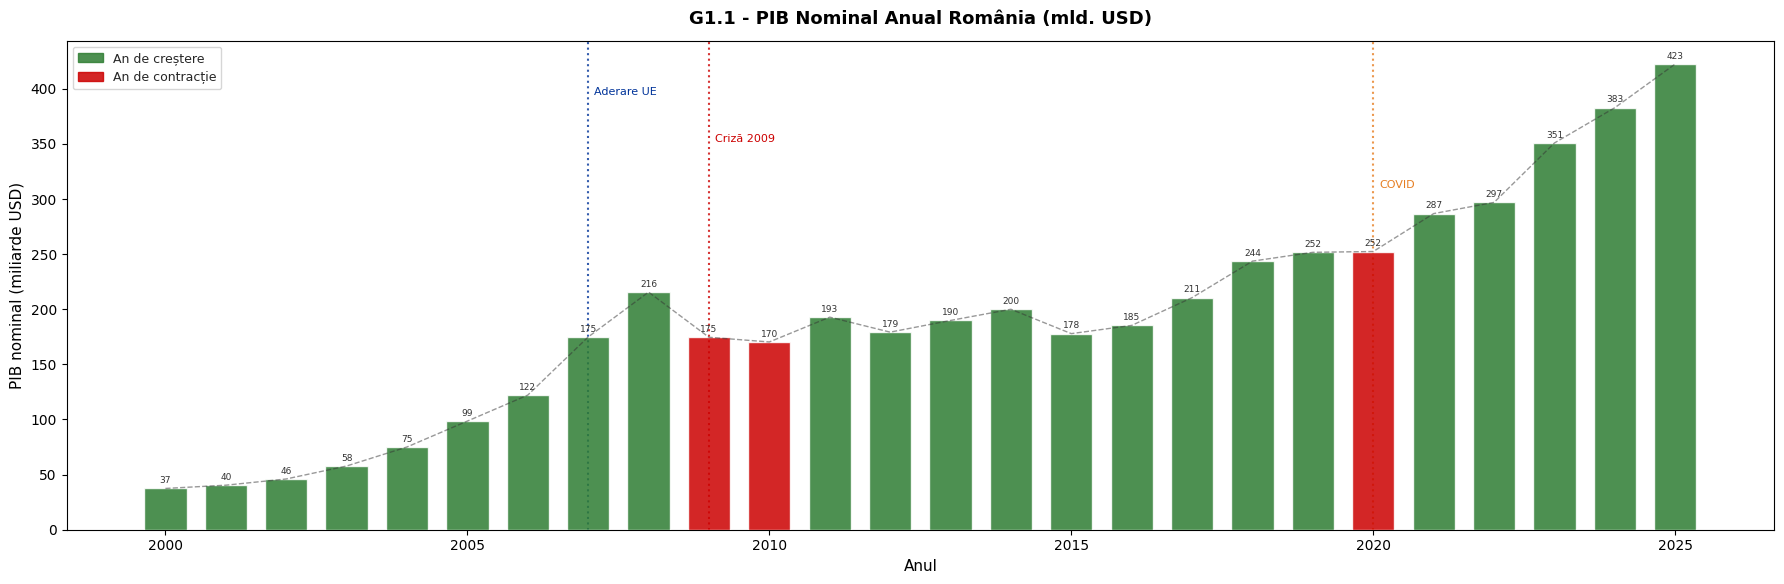

In [16]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_p = df_pib_nom.copy()
df_p['pib_mld'] = df_p['pib_nominal_usd'] / 1e9
culori_bare = [CUL['verde'] if v > 0 else CUL['rosu'] for v in df_p['crestere_pib_pct'].fillna(1)]

ax.bar(df_p['an'], df_p['pib_mld'], color=culori_bare, alpha=0.85, width=0.7, zorder=3)

# Etichete pe bare
for _, row in df_p.iterrows():
    if not pd.isna(row['pib_mld']):
        ax.text(row['an'], row['pib_mld'] + 3, f"{row['pib_mld']:.0f}",
                ha='center', va='bottom', fontsize=6.5, color='#333333')

# Linie de tendință
ax.plot(df_p['an'], df_p['pib_mld'], color='#333333', linewidth=1, linestyle='--', alpha=0.5, zorder=4)

ax.axvline(x=2007, color=CUL['ue'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2007.1, df_p['pib_mld'].max() * 0.95, 'Aderare UE', color=CUL['ue'], fontsize=8, va='top')
ax.axvline(x=2009, color=CUL['rosu'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2009.1, df_p['pib_mld'].max() * 0.85, 'Criză 2009', color=CUL['rosu'], fontsize=8, va='top')
ax.axvline(x=2020, color=CUL['portoc'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2020.1, df_p['pib_mld'].max() * 0.75, 'COVID', color=CUL['portoc'], fontsize=8, va='top')

ax.set_xlabel('Anul', fontsize=11)
ax.set_ylabel('PIB nominal (miliarde USD)', fontsize=11)
ax.set_title('G1.1 - PIB Nominal Anual România (mld. USD)', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

patch_v = mpatches.Patch(color=CUL['verde'], alpha=0.85, label='An de creștere')
patch_r = mpatches.Patch(color=CUL['rosu'], alpha=0.85, label='An de contracție')
ax.legend(handles=[patch_v, patch_r], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

#### G1.2 - PIB trimestrial: România vs. Euro Area (indice volum, 2020=100)
**Tipul graficului:** Linie multi-serie  
**Mesajul:** România crește mai rapid decât zona euro - dar și cade mai abrupt în crize.


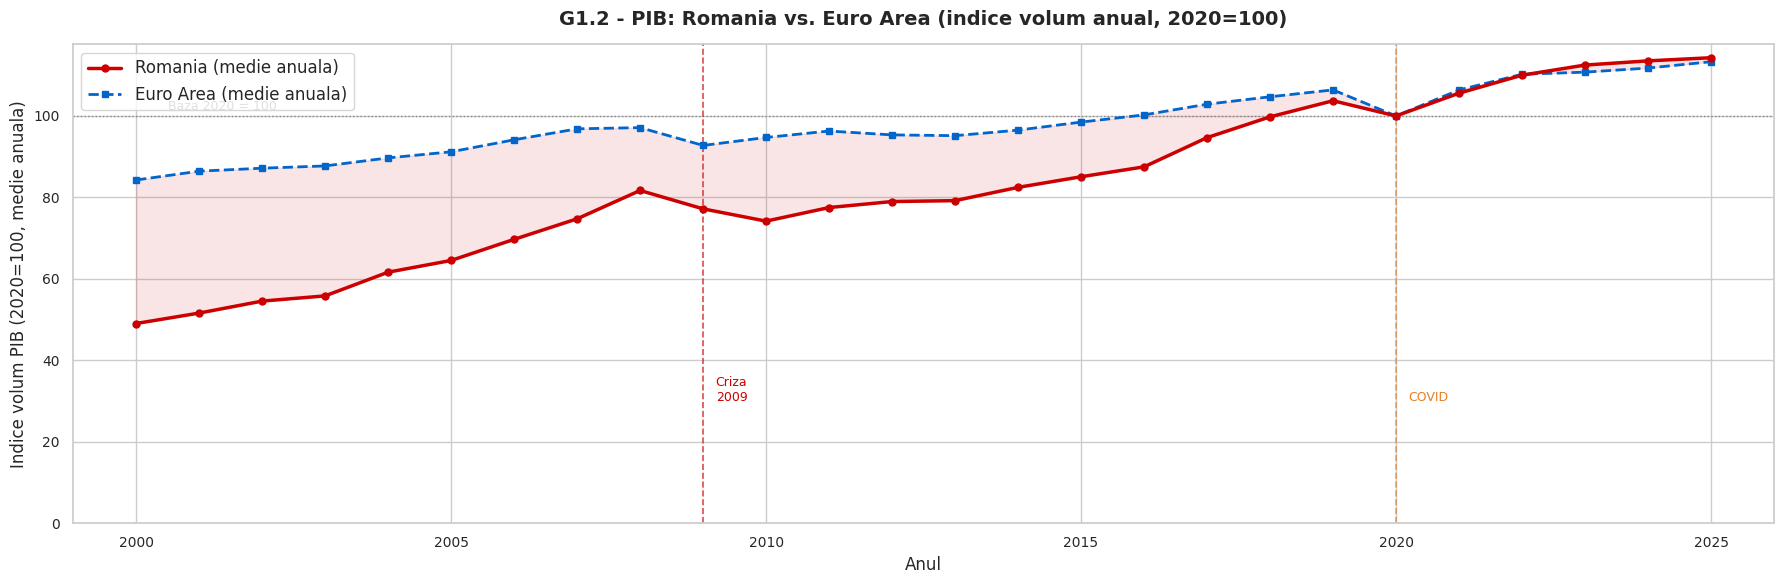

In [17]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

# Agregam la nivel anual pentru a elimina sezonalitatea puternica
df_pib_an = df_pib_trim.groupby('an')[['pib_romania_idx','pib_euroarea_idx']].mean().reset_index()
df_pib_an = df_pib_an[df_pib_an['an'] <= 2025]

ax.plot(df_pib_an['an'], df_pib_an['pib_romania_idx'],
        color=CUL['ro'], linewidth=2.5, marker='o', markersize=5,
        label='Romania (medie anuala)', zorder=4)
ax.plot(df_pib_an['an'], df_pib_an['pib_euroarea_idx'],
        color=CUL['ea'], linewidth=2, linestyle='--', marker='s', markersize=4,
        label='Euro Area (medie anuala)', zorder=3)
ax.fill_between(df_pib_an['an'], df_pib_an['pib_romania_idx'],
                df_pib_an['pib_euroarea_idx'], alpha=0.1, color=CUL['ro'])

ax.axhline(y=100, color='#666666', linewidth=1, linestyle=':', alpha=0.7)
ax.text(2000.5, 101.5, 'Baza 2020 = 100', fontsize=9, color='#666666')

ax.axvline(x=2009, color=CUL['rosu'], linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(2009.2, 30, 'Criza\n2009', color=CUL['rosu'], fontsize=9)
ax.axvline(x=2020, color=CUL['portoc'], linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(2020.2, 30, 'COVID', color=CUL['portoc'], fontsize=9)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('Indice volum PIB (2020=100, medie anuala)', fontsize=12)
ax.set_title('G1.2 - PIB: Romania vs. Euro Area (indice volum anual, 2020=100)', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=12, loc='upper left')
ax.set_xlim(1999, 2026)
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

#### G1.3 -  PIB, Inflație, Creștere simultane

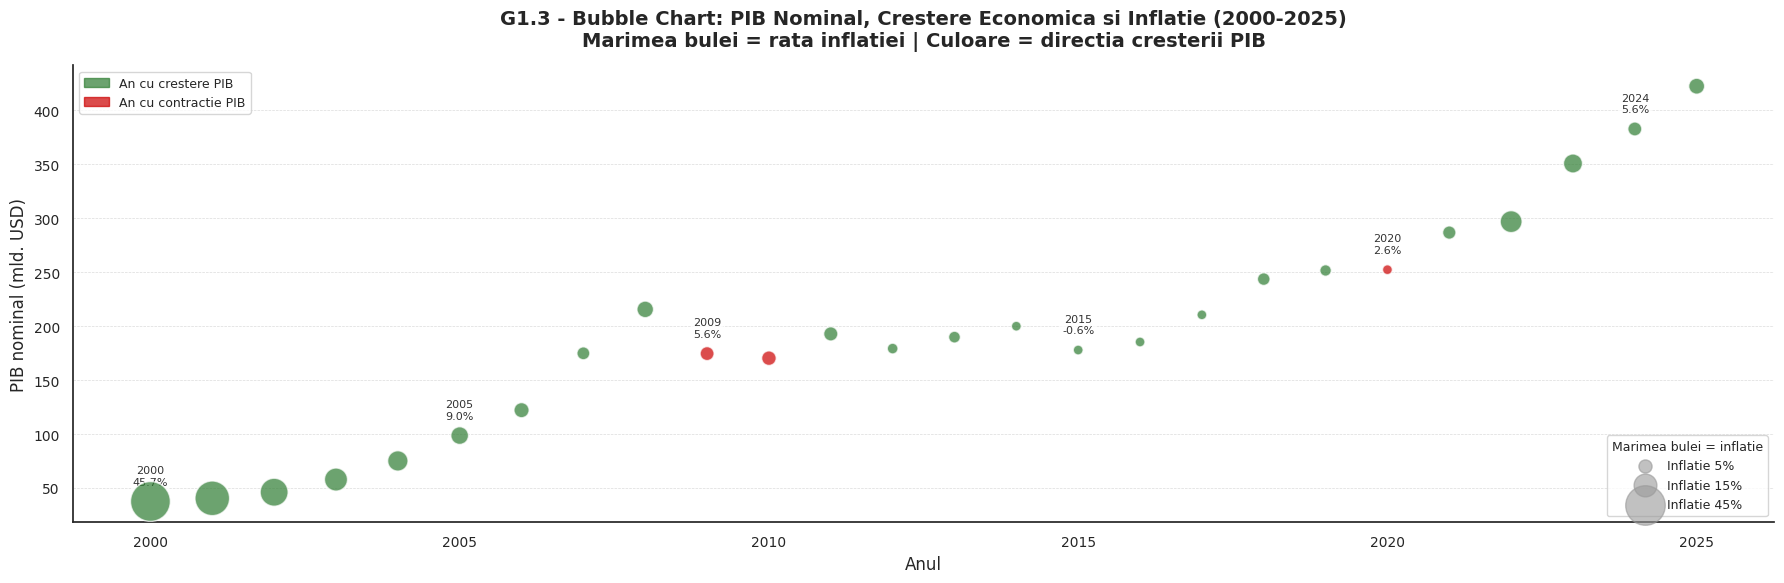

In [74]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_bubble = df_pib_nom.merge(df_inflatie, on='an')
df_bubble = df_bubble.dropna(subset=['pib_nominal_usd',
                                     'rata_inflatie_pct',
                                     'crestere_pib_pct'])

culori_bule = [CUL['verde'] if v > 0 else CUL['ro']
               for v in df_bubble['crestere_pib_pct']]

marimi = df_bubble['rata_inflatie_pct'].abs() * 18
marimi = marimi.clip(lower=50)

ax.scatter(df_bubble['an'], df_bubble['pib_nominal_usd'] / 1e9,
           s=marimi, c=culori_bule, alpha=0.7,
           edgecolors='white', linewidths=1, zorder=4)

for _, row in df_bubble.iterrows():
    if row['an'] in [2000, 2005, 2009, 2015, 2020, 2024]:
        ax.annotate(
            f"{int(row['an'])}\n{row['rata_inflatie_pct']:.1f}%",
            xy=(row['an'], row['pib_nominal_usd']/1e9),
            xytext=(0, 12), textcoords='offset points',
            ha='center', fontsize=8, color='#333333',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', edgecolor='none', alpha=0.8))

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Legenda 1: culori
p_v = mpatches.Patch(color=CUL['verde'], alpha=0.7, label='An cu crestere PIB')
p_r = mpatches.Patch(color=CUL['ro'],    alpha=0.7, label='An cu contractie PIB')
leg1 = ax.legend(handles=[p_v, p_r], loc='upper left', fontsize=9)
ax.add_artist(leg1)

# Legenda 2: dimensiuni bule — construita corect
h_dim = [
    ax.scatter([], [], s=5*18,  color='#999999', alpha=0.6, label='Inflatie 5%'),
    ax.scatter([], [], s=15*18, color='#999999', alpha=0.6, label='Inflatie 15%'),
    ax.scatter([], [], s=45*18, color='#999999', alpha=0.6, label='Inflatie 45%'),
]
leg2 = ax.legend(handles=h_dim, loc='lower right', fontsize=9,
                 title='Marimea bulei = inflatie', title_fontsize=9)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('PIB nominal (mld. USD)', fontsize=12)
ax.set_title('G1.3 - Bubble Chart: PIB Nominal, Crestere Economica si Inflatie (2000-2025)\n'
             'Marimea bulei = rata inflatiei | Culoare = directia cresterii PIB',
             fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

---
### 📈 Capitol 2 - Inflație și Politică Monetară BNR

România a traversat trei episoade inflaționiste distincte: tranziția (2000–2004), șocul energetic pre-criză (2007–2008) și șocul post-pandemic (2022–2023, vârf 16.4%).


#### G2.1 - Inflație IPC lunar + Dobânda BNR (ax dual, 2003–2026)
**Tipul graficului:** Linie cu două axe Y (`twinx`)  
**Mesajul:** BNR reacționează cu creșteri de dobândă la fiecare episod inflaționist - lag vizibil de 2–3 trimestre.


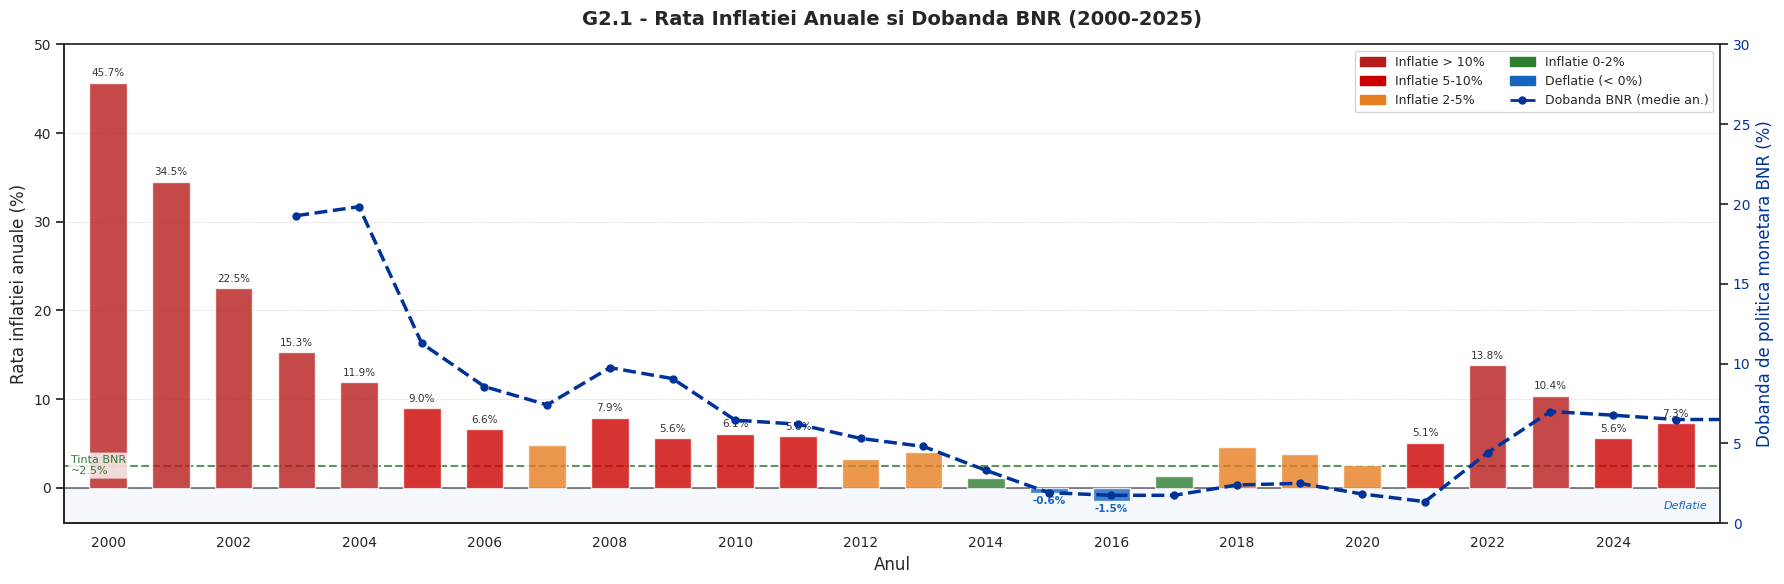

In [24]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')  # fara grid implicit

df_inf = df_inflatie.copy()

culori_inf = []
for v in df_inf['rata_inflatie_pct']:
    if v > 10:   culori_inf.append('#B71C1C')
    elif v > 5:  culori_inf.append(CUL['ro'])
    elif v > 2:  culori_inf.append(CUL['portoc'])
    elif v >= 0: culori_inf.append(CUL['verde'])
    else:        culori_inf.append('#1565C0')

ax1.bar(df_inf['an'], df_inf['rata_inflatie_pct'],
        color=culori_inf, alpha=0.80, width=0.6, zorder=3)

# Doar grid orizontal, subtil
ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)

ax1.axhline(y=0,   color='#333333', linewidth=1.2, linestyle='-',  alpha=0.7)
ax1.axhline(y=2.5, color=CUL['verde'], linewidth=1.5, linestyle='--', alpha=0.8)
ax1.text(1999.4, 2.5, 'Tinta BNR\n~2.5%', fontsize=8, color=CUL['verde'],
         va='center', ha='left',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

ax1.set_ylabel('Rata inflatiei anuale (%)', fontsize=12)
ax1.tick_params(axis='y', labelsize=10)
ax1.set_ylim(-4, 50)

for _, row in df_inf.iterrows():
    if row['rata_inflatie_pct'] > 5:
        ax1.text(row['an'], row['rata_inflatie_pct'] + 0.5,
                 f"{row['rata_inflatie_pct']:.1f}%",
                 ha='center', va='bottom', fontsize=7.5, color='#333333')

for _, row in df_inf.iterrows():
    if row['rata_inflatie_pct'] < 0:
        ax1.text(row['an'], row['rata_inflatie_pct'] - 0.3,
                 f"{row['rata_inflatie_pct']:.1f}%",
                 ha='center', va='top', fontsize=7.5,
                 color='#1565C0', fontweight='bold')

ax1.axhspan(-4, 0, alpha=0.04, color='#1565C0', zorder=0)
ax1.text(2025.5, -2, 'Deflatie', fontsize=8, color='#1565C0',
         style='italic', ha='right', va='center')

ax2 = ax1.twinx()
df_bnr_an = df_bnr.copy()
df_bnr_an['an'] = df_bnr_an['data'].dt.year
df_bnr_anual = df_bnr_an.groupby('an')['dobanda_pm'].mean().reset_index()
df_bnr_anual = df_bnr_anual[df_bnr_anual['an'] >= 2000]

ax2.plot(df_bnr_anual['an'], df_bnr_anual['dobanda_pm'],
         color=CUL['ue'], linewidth=2.5, marker='o', markersize=5,
         linestyle='--', zorder=5)
ax2.set_ylabel('Dobanda de politica monetara BNR (%)', color=CUL['ue'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=CUL['ue'], labelsize=10)
ax2.set_ylim(0, 30)
ax2.yaxis.grid(False)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
p1 = mpatches.Patch(color='#B71C1C', label='Inflatie > 10%')
p2 = mpatches.Patch(color=CUL['ro'],     label='Inflatie 5-10%')
p3 = mpatches.Patch(color=CUL['portoc'], label='Inflatie 2-5%')
p4 = mpatches.Patch(color=CUL['verde'],  label='Inflatie 0-2%')
p5 = mpatches.Patch(color='#1565C0',    label='Deflatie (< 0%)')
l1 = Line2D([0],[0], color=CUL['ue'], linewidth=2, linestyle='--',
            marker='o', markersize=5, label='Dobanda BNR (medie an.)')
ax1.legend(handles=[p1, p2, p3, p4, p5, l1], loc='upper right', fontsize=9, ncol=2)

ax1.set_xlabel('Anul', fontsize=12)
ax1.set_title('G2.1 - Rata Inflatiei Anuale si Dobanda BNR (2000-2025)',
              fontsize=14, fontweight='bold', pad=14)
ax1.set_xlim(1999.3, 2025.7)
ax1.set_xticks(range(2000, 2026, 2))
ax1.tick_params(axis='x', labelsize=10)

# Spine curate
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

#### G2.2 - HICP lunar: România vs. UE-27 (variație lunară %, 2000–2025)
**Tipul graficului:** Linie multi-serie  
**Mesajul:** România înregistrează constant volatilitate mai mare față de media UE - structural, nu conjunctural.


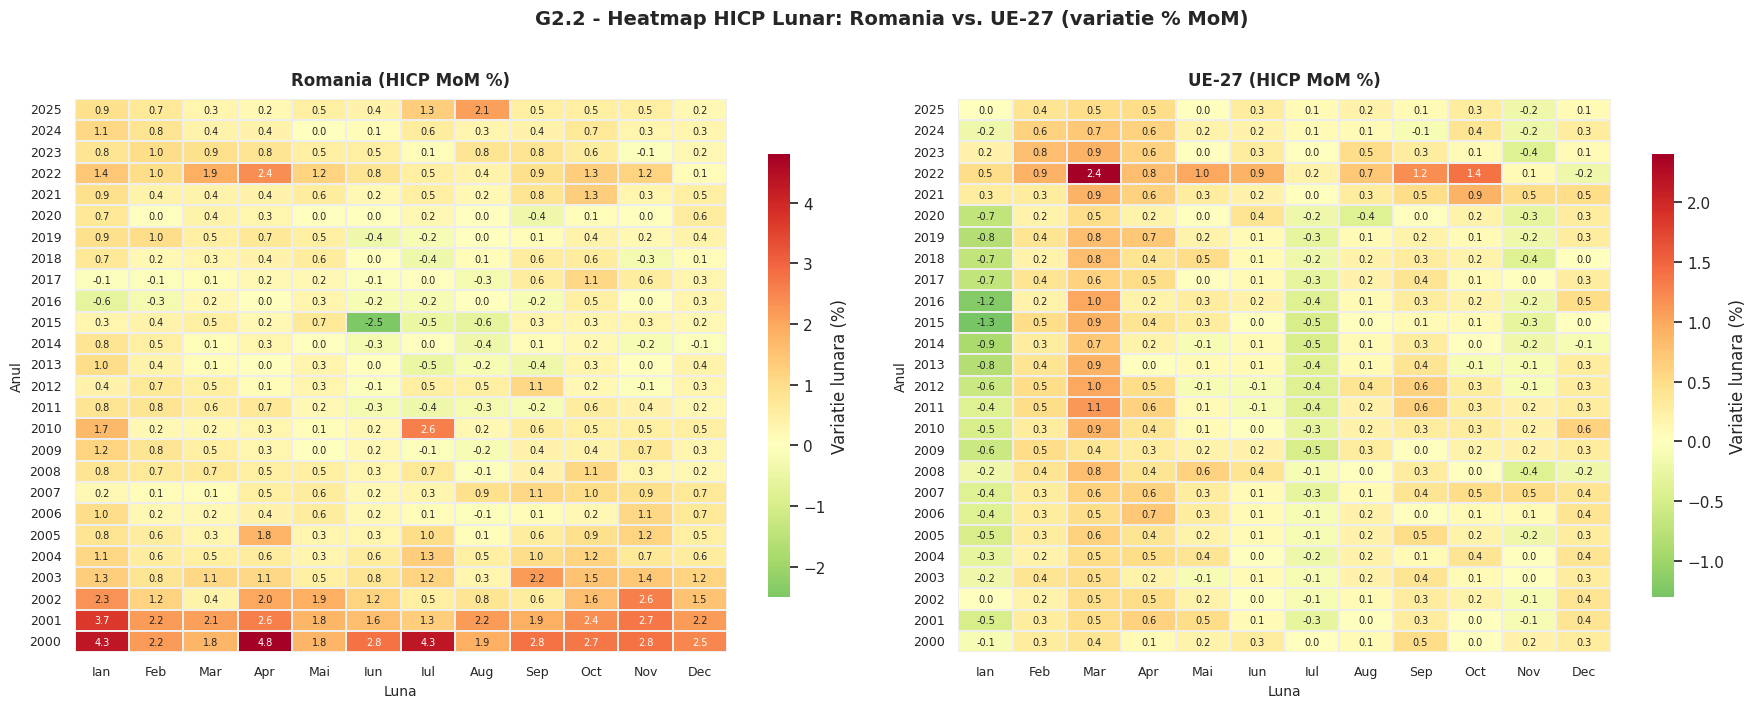

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set(style='white')

df_h = df_hicp.copy()
df_h['an']   = df_h['data'].dt.year
df_h['luna'] = df_h['data'].dt.month

luni_label = ['Ian','Feb','Mar','Apr','Mai','Iun',
              'Iul','Aug','Sep','Oct','Nov','Dec']

for idx, (col, titlu, cmap) in enumerate([
    ('hicp_ro', 'Romania (HICP MoM %)', 'RdYlGn_r'),
    ('hicp_ue', 'UE-27 (HICP MoM %)',  'RdYlGn_r'),
]):
    ax = axes[idx]
    pivot = df_h.pivot_table(index='an', columns='luna', values=col, aggfunc='mean')
    pivot.columns = luni_label
    pivot = pivot.sort_index(ascending=False)

    sns.heatmap(pivot, ax=ax, cmap=cmap, center=0,
                annot=True, fmt='.1f', annot_kws={'size': 7},
                linewidths=0.3, linecolor='#eeeeee',
                cbar_kws={'label': 'Variatie lunara (%)', 'shrink': 0.8})

    ax.set_title(titlu, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Luna', fontsize=10)
    ax.set_ylabel('Anul', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

fig.suptitle('G2.2 - Heatmap HICP Lunar: Romania vs. UE-27 (variatie % MoM)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### G2.3 - Distribuția Inflației Lunare

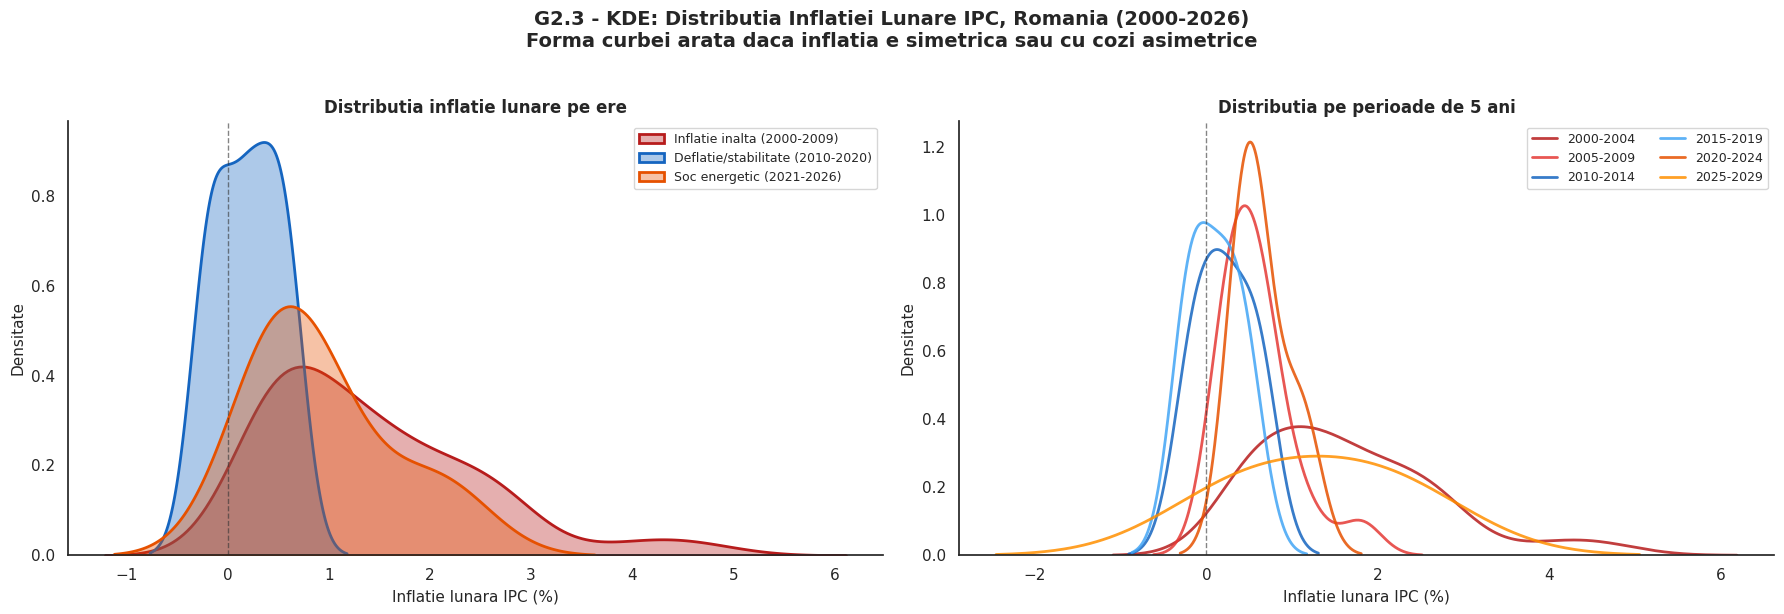

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set(style='white')

df_kde = df_ipc.copy()
df_kde['ipc_pct'] = (df_kde['ipc_mom'] / 10.0) - 100.0
df_kde = df_kde[(df_kde['ipc_pct'] > -5) & (df_kde['ipc_pct'] < 15)]
df_kde['era'] = df_kde['data'].dt.year.apply(
    lambda x: 'Inflatie inalta (2000-2009)' if x < 2010
    else ('Deflatie/stabilitate (2010-2020)' if x < 2021
          else 'Soc energetic (2021-2026)'))

culori_era = {
    'Inflatie inalta (2000-2009)':      '#B71C1C',
    'Deflatie/stabilitate (2010-2020)': '#1565C0',
    'Soc energetic (2021-2026)':        '#E65100'
}

# Stanga: KDE per era
ax1 = axes[0]
for era, culoare in culori_era.items():
    subset = df_kde[df_kde['era'] == era]['ipc_pct']
    sns.kdeplot(subset, ax=ax1, fill=True, alpha=0.35,
                color=culoare, label=era, linewidth=2)

ax1.axvline(x=0, color='#333333', linewidth=1, linestyle='--', alpha=0.6)
ax1.set_xlabel('Inflatie lunara IPC (%)', fontsize=11)
ax1.set_ylabel('Densitate', fontsize=11)
ax1.set_title('Distributia inflatie lunare pe ere', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# Dreapta: KDE per decada cu rugplot
ax2 = axes[1]
df_kde['decada'] = (df_kde['data'].dt.year // 5 * 5).astype(str)
palette_dec = {'2000': '#B71C1C', '2005': '#E53935', '2010': '#1565C0',
               '2015': '#42A5F5', '2020': '#E65100', '2025': '#FF8F00'}

for decada in sorted(df_kde['decada'].unique()):
    subset = df_kde[df_kde['decada'] == decada]['ipc_pct']
    c = palette_dec.get(decada, '#888888')
    sns.kdeplot(subset, ax=ax2, color=c, linewidth=2,
                label=f'{decada}-{int(decada)+4}', alpha=0.85)

ax2.axvline(x=0, color='#333333', linewidth=1, linestyle='--', alpha=0.6)
ax2.set_xlabel('Inflatie lunara IPC (%)', fontsize=11)
ax2.set_ylabel('Densitate', fontsize=11)
ax2.set_title('Distributia pe perioade de 5 ani', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, ncol=2)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

fig.suptitle('G2.3 - KDE: Distributia Inflatiei Lunare IPC, Romania (2000-2026)\n'
             'Forma curbei arata daca inflatia e simetrica sau cu cozi asimetrice',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 💱 Capitol 3 - Curs Valutar

EUR/RON a rămas remarcabil de stabil față de PLN și HUF - o anomalie regională care generează atât avantaje (predictibilitate) cât și întrebări despre supraevaluare și flexibilitate economică.


#### G3.1 - Cursuri indexate EUR/RON, EUR/PLN, EUR/HUF (baza iulie 2005=100)
**Tipul graficului:** Linie multi-serie pe date lunare  
**Mesajul:** RON s-a depreciat moderat față de EUR, în timp ce PLN și HUF au oscilat violent - mai ales HUF după 2022.


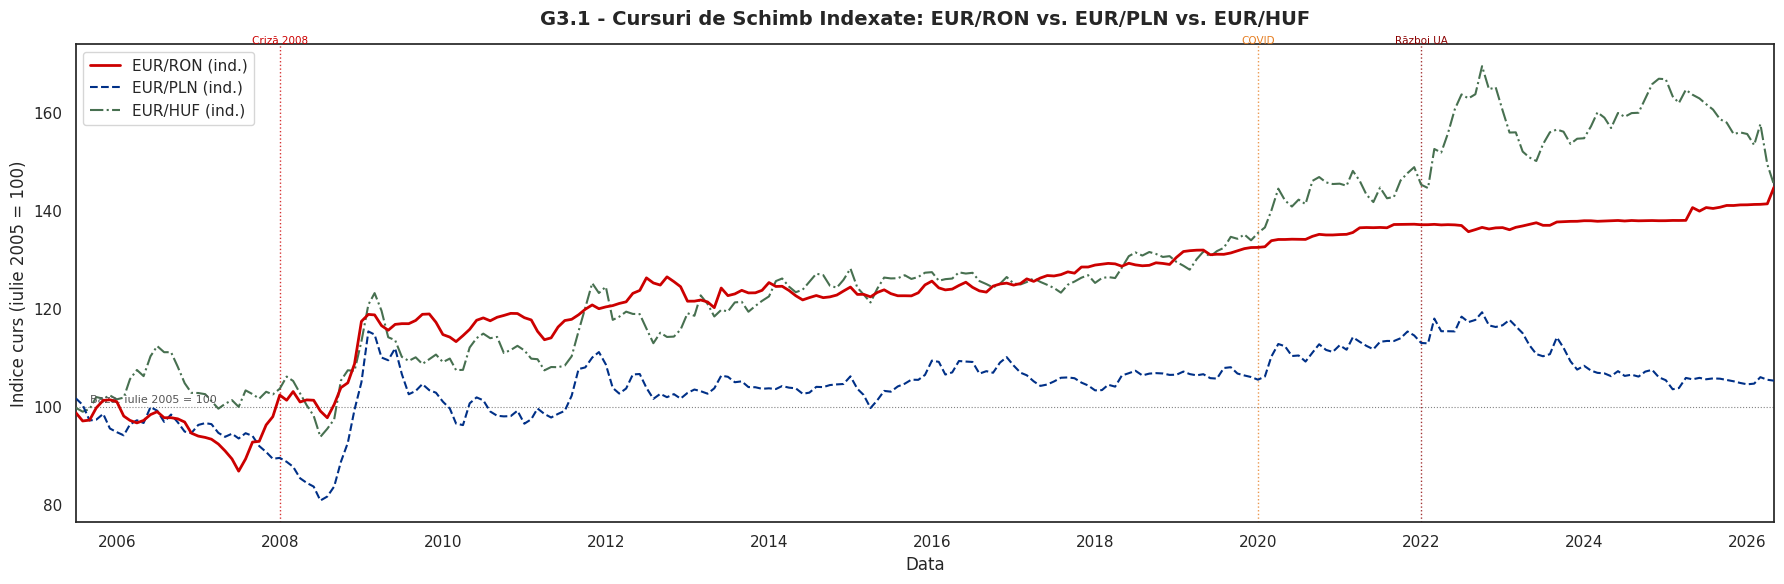

In [78]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

ax.plot(df_curs_lunar['data'], df_curs_lunar['ron_idx'],
        color=CUL['ro'], linewidth=2, label='EUR/RON (ind.)', zorder=5)
ax.plot(df_curs_lunar['data'], df_curs_lunar['pln_idx'],
        color=CUL['pln'], linewidth=1.5, linestyle='--', label='EUR/PLN (ind.)', zorder=4)
ax.plot(df_curs_lunar['data'], df_curs_lunar['huf_idx'],
        color=CUL['huf'], linewidth=1.5, linestyle='-.', label='EUR/HUF (ind.)', zorder=3)

ax.axhline(y=100, color='#333333', linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(df_curs_lunar['data'].iloc[2], 101, 'Baza: iulie 2005 = 100', fontsize=8, color='#555555')

for an, label, culoare in [(2008, 'Criză 2008', CUL['rosu']),
                            (2020, 'COVID', CUL['portoc']),
                            (2022, 'Război UA', '#8B0000')]:
    ax.axvline(x=pd.Timestamp(str(an)), color=culoare, linewidth=1, linestyle=':', alpha=0.8)
    ax.text(pd.Timestamp(str(an)), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 160,
            label, ha='center', fontsize=7.5, color=culoare)

ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Indice curs (iulie 2005 = 100)', fontsize=12)
ax.set_title('G3.1 - Cursuri de Schimb Indexate: EUR/RON vs. EUR/PLN vs. EUR/HUF', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(df_curs_lunar['data'].min(), df_curs_lunar['data'].max())

plt.tight_layout()
plt.show()

#### **G3.2 - Distribuția anuală EUR/RON (volatilitate zilnică pe ani)**

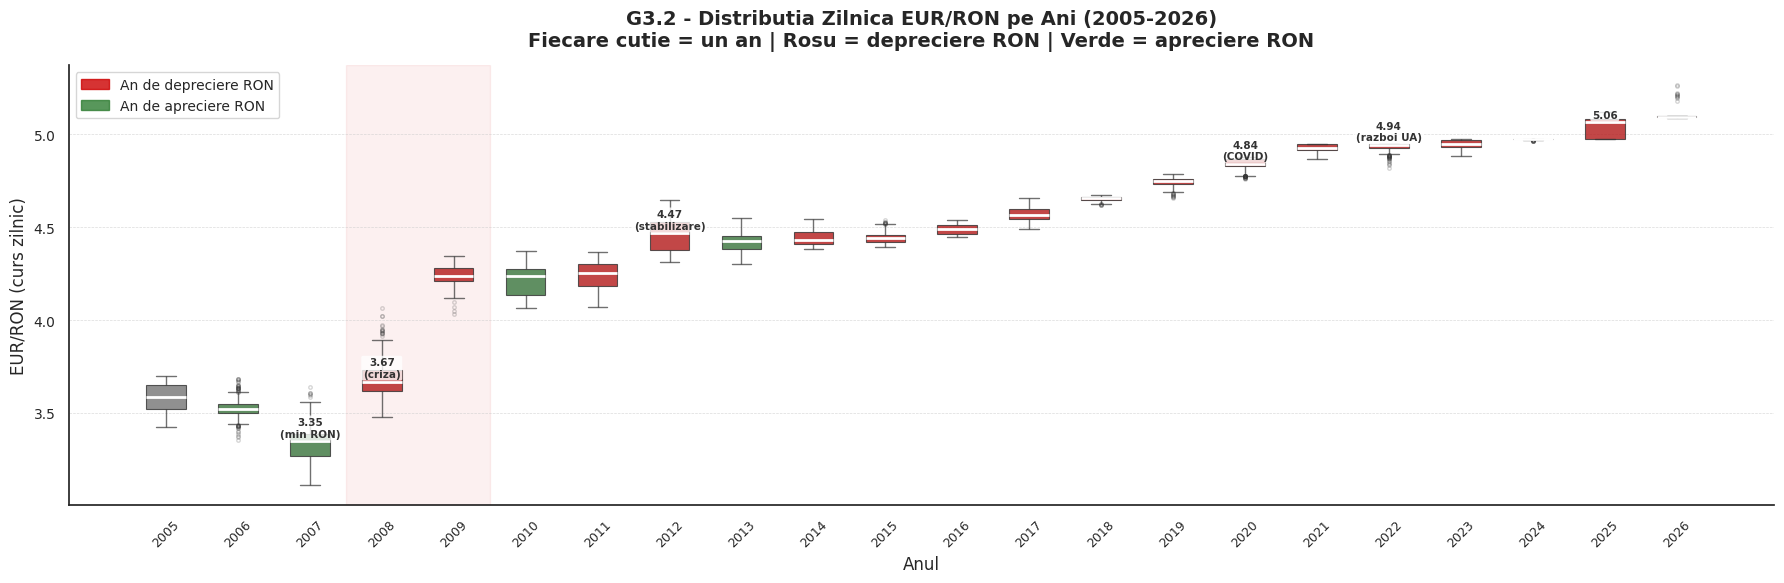

In [69]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_box = df_curs.copy()
df_box['an'] = df_box['data'].dt.year

# Culori: verde pentru ani de apreciere RON, rosu pentru depreciere
ani_unici = sorted(df_box['an'].unique())
mediane = df_box.groupby('an')['eur_ron'].median()
culori_box = []
for i, an in enumerate(ani_unici):
    if i == 0:
        culori_box.append(CUL['gri'])
    else:
        culori_box.append(CUL['ro'] if mediane[an] > mediane[ani_unici[i-1]]
                          else CUL['verde'])

sns.boxplot(data=df_box, x='an', y='eur_ron', ax=ax,
            palette=culori_box, width=0.55, fliersize=1.5,
            flierprops=dict(marker='o', alpha=0.2, markersize=2.5),
            medianprops=dict(color='white', linewidth=2),
            whiskerprops=dict(linewidth=1, alpha=0.7),
            capprops=dict(linewidth=1, alpha=0.7),
            boxprops=dict(alpha=0.8),
            linewidth=0.8)

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Etichete mediana doar la ani cheie cu valori semnificative
ani_cheie = {2007: 'min RON', 2008: 'criza', 2012: 'stabilizare',
             2020: 'COVID', 2022: 'razboi UA', 2025: None}
for an_ref, nota in ani_cheie.items():
    if an_ref not in mediane.index: continue
    med = mediane[an_ref]
    pos = ani_unici.index(an_ref)
    eticheta = f'{med:.2f}' if nota is None else f'{med:.2f}\n({nota})'
    ax.text(pos, med + 0.015, eticheta,
            ha='center', va='bottom', fontsize=7.5,
            color='#333333', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor='none', alpha=0.8))

# Zona crizei 2008
ax.axvspan(ani_unici.index(2008) - 0.5,
           ani_unici.index(2009) + 0.5,
           alpha=0.06, color=CUL['ro'], zorder=0)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

import matplotlib.patches as mpatches
p_dep = mpatches.Patch(color=CUL['ro'],    alpha=0.8, label='An de depreciere RON')
p_apr = mpatches.Patch(color=CUL['verde'], alpha=0.8, label='An de apreciere RON')
ax.legend(handles=[p_dep, p_apr], fontsize=10, loc='upper left')

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('EUR/RON (curs zilnic)', fontsize=12)
ax.set_title('G3.2 - Distributia Zilnica EUR/RON pe Ani (2005-2026)\n'
             'Fiecare cutie = un an | Rosu = depreciere RON | Verde = apreciere RON',
             fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

---
### 👷 Capitol 4 - Piața Muncii

O poveste în trei acte: șomaj ridicat la tranziție, scădere după aderarea UE (cu milioane de emigranți), și o piață a muncii tensionată post-2017 - salarii în creștere rapidă, șomaj structural scăzut.


#### G4.1 - Rata Șomajului BIM trimestrial (%, 2000–2025)
**Tipul graficului:** Linie cu fill sub curbă  
**Mesajul:** Șomajul a scăzut constant după 2013 - dar emigrația a contribuit la această reducere, nu doar crearea de locuri de muncă.


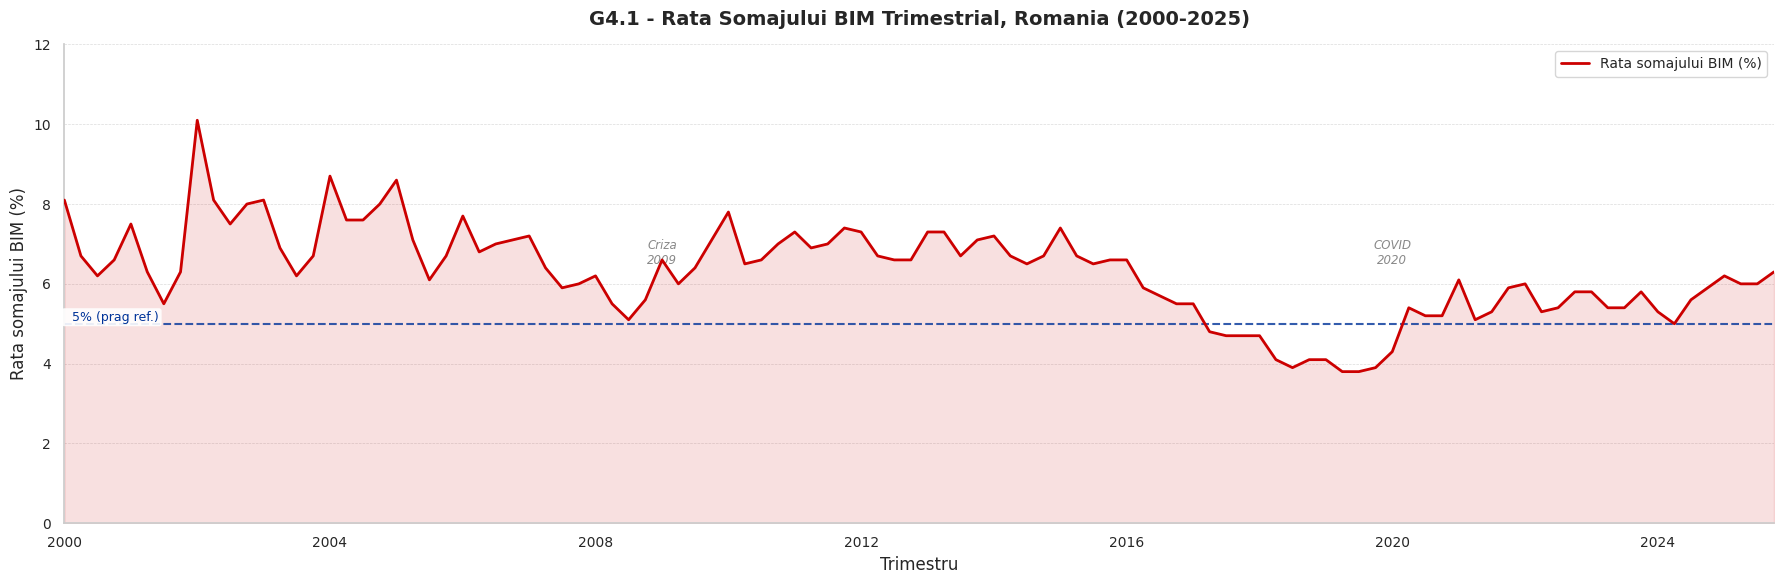

In [30]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

ax.plot(df_somaj_trim['data'], df_somaj_trim['somaj_pct'],
        color=CUL['ro'], linewidth=2, zorder=4, label='Rata somajului BIM (%)')
ax.fill_between(df_somaj_trim['data'], df_somaj_trim['somaj_pct'],
                alpha=0.12, color=CUL['ro'])

# Grid orizontal subtil, fara vertical
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Prag 5% cu text pe marginea stanga
ax.axhline(y=5, color=CUL['ue'], linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(df_somaj_trim['data'].iloc[0], 5, '  5% (prag ref.)',
        ha='left', va='bottom', fontsize=9, color=CUL['ue'],
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# Fara linii verticale - doar adnotare text simpla
ax.annotate('Criza\n2009', xy=(pd.Timestamp('2009-01-01'), 6.5),
            fontsize=8.5, color='#888888', ha='center', style='italic')
ax.annotate('COVID\n2020', xy=(pd.Timestamp('2020-01-01'), 6.5),
            fontsize=8.5, color='#888888', ha='center', style='italic')

ax.set_xlabel('Trimestru', fontsize=12)
ax.set_ylabel('Rata somajului BIM (%)', fontsize=12)
ax.set_title('G4.1 - Rata Somajului BIM Trimestrial, Romania (2000-2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(df_somaj_trim['data'].min(), df_somaj_trim['data'].max())
ax.set_ylim(0, 12)
ax.tick_params(axis='both', labelsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

#### G4.2 - Salariul Minim pe Economie (RON brut, step chart)
**Tipul graficului:** Step chart - fiecare modificare legislativă e vizibilă ca salt  
**Mesajul:** Salariul minim a crescut de ~14× în 20 de ani - de la 310 RON (2005) la 4.325 RON (2026).


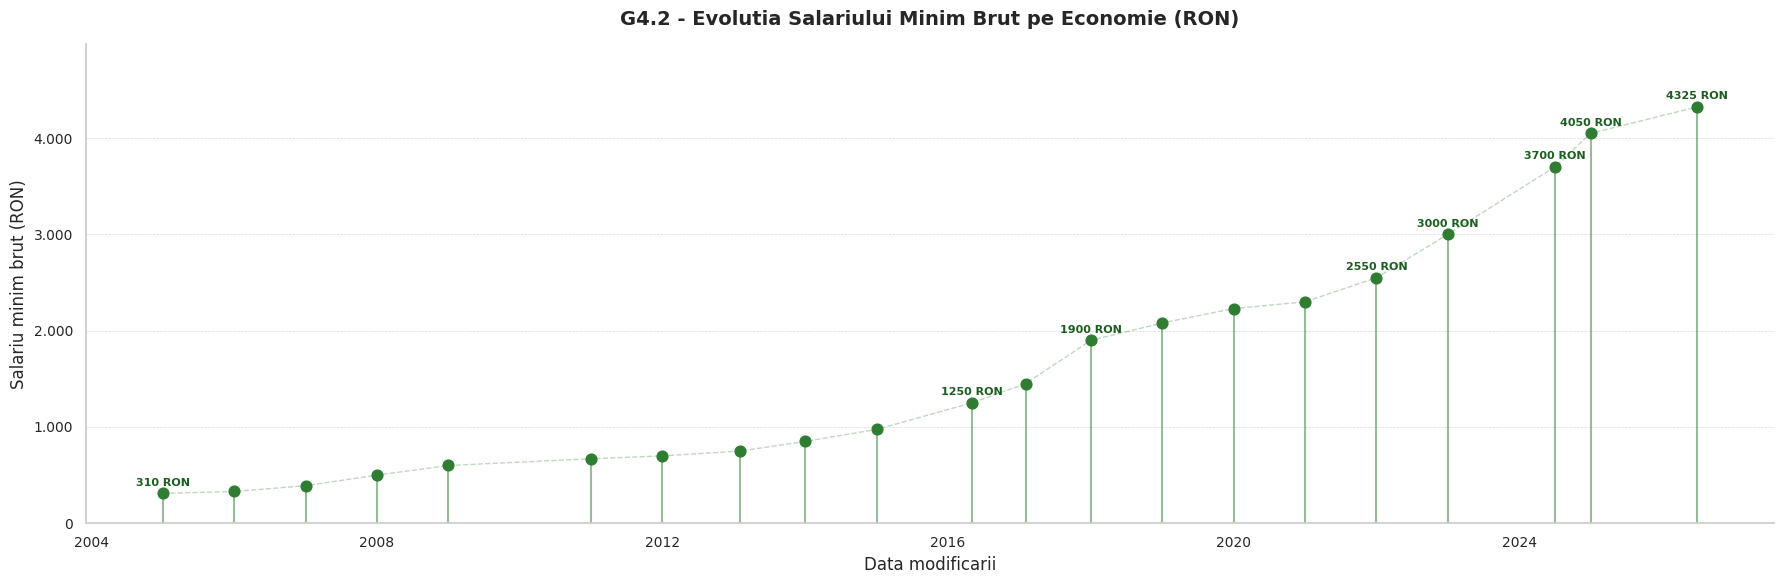

In [34]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_s = df_sal_min.dropna(subset=['salariu_minim_brut_ron']).sort_values('data')

# Linii verticale de la 0 la valoare
ax.vlines(df_s['data'], 0, df_s['salariu_minim_brut_ron'],
          color=CUL['verde'], linewidth=1.5, alpha=0.5)

# Puncte
ax.scatter(df_s['data'], df_s['salariu_minim_brut_ron'],
           color=CUL['verde'], s=60, zorder=5)

# Linie de conectare subtila
ax.plot(df_s['data'], df_s['salariu_minim_brut_ron'],
        color=CUL['verde'], linewidth=1, linestyle='--', alpha=0.3, zorder=3)

# Etichete doar la salturi > 200 RON
prev = 0
for _, row in df_s.iterrows():
    val = row['salariu_minim_brut_ron']
    if val - prev > 200:
        ax.text(row['data'], val + 60,
                f"{int(val)} RON",
                ha='center', va='bottom', fontsize=8, color='#1B5E20', fontweight='bold')
    prev = val

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Data modificarii', fontsize=12)
ax.set_ylabel('Salariu minim brut (RON)', fontsize=12)
ax.set_title('G4.2 - Evolutia Salariului Minim Brut pe Economie (RON)',
             fontsize=14, fontweight='bold', pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))
ax.set_ylim(0, df_s['salariu_minim_brut_ron'].max() * 1.15)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

#### G4.3 - Câștigul Salarial Mediu Net Lunar (RON, 2000–2025)
**Tipul graficului:** Linie cu fill și medie mobilă  
**Mesajul:** Salariul net mediu a crescut de ~34× în 25 de ani - de la 173 RON (2000) la ~5.900 RON (2025).


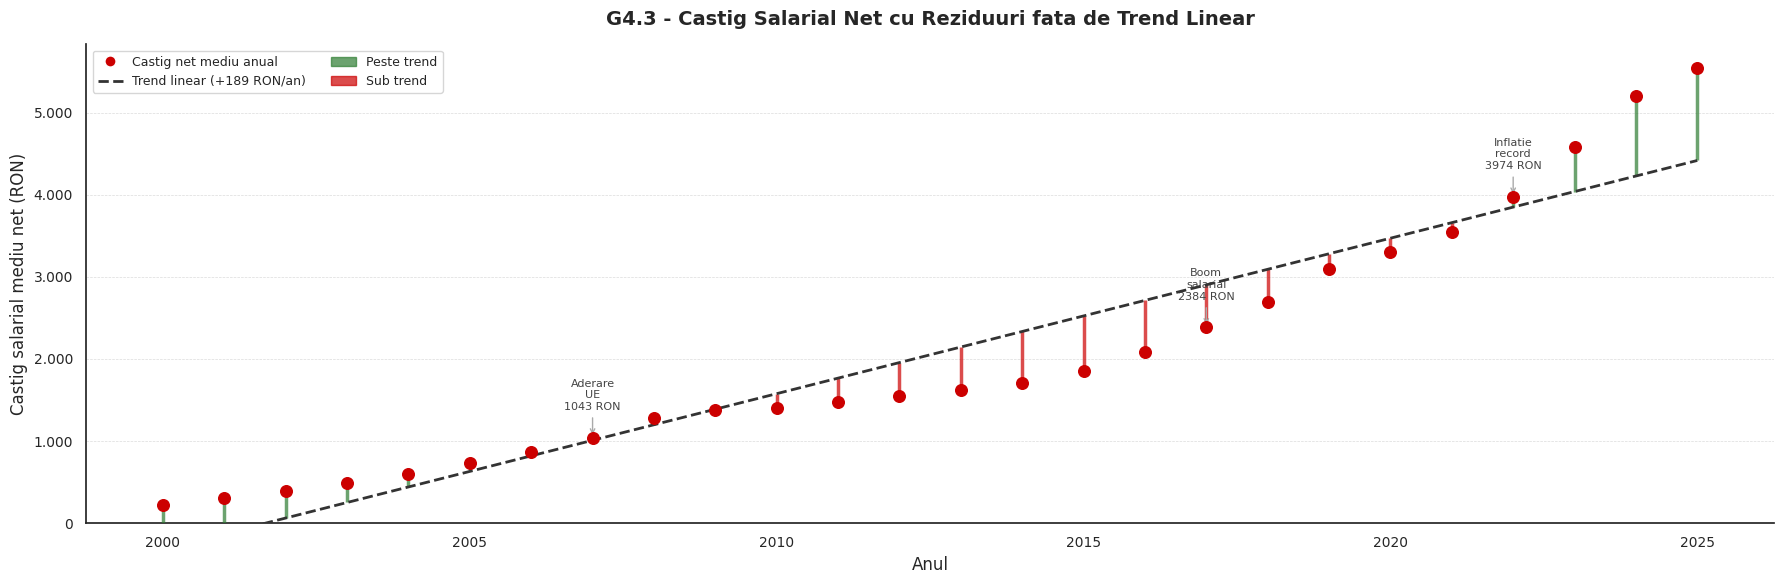

In [66]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

import numpy as np

df_c = df_castig.copy()
df_c['an'] = df_c['data'].dt.year
df_an = df_c.groupby('an')['castig_net_total_ron'].mean().reset_index()
df_an.columns = ['an', 'medie']

# Regresia liniara
z = np.polyfit(df_an['an'], df_an['medie'], 1)
p = np.poly1d(z)
df_an['trend'] = p(df_an['an'])
df_an['reziduu'] = df_an['medie'] - df_an['trend']

# Linii de reziduu: de la valoarea reala la trend
for _, row in df_an.iterrows():
    culoare = CUL['verde'] if row['reziduu'] > 0 else CUL['ro']
    ax.vlines(row['an'], row['trend'], row['medie'],
              color=culoare, linewidth=2.5, alpha=0.7, zorder=3)

# Trend
x_reg = np.linspace(df_an['an'].min(), df_an['an'].max(), 100)
ax.plot(x_reg, p(x_reg), color='#333333', linewidth=2,
        linestyle='--', label=f'Trend linear (+{z[0]:.0f} RON/an)', zorder=4)

# Puncte
ax.scatter(df_an['an'], df_an['medie'],
           color=CUL['ro'], s=70, zorder=6, label='Castig net mediu anual')

# Grid subtil
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Etichete la ani cheie
for an_ref, label in [(2007,'Aderare\nUE'), (2017,'Boom\nsalarial'), (2022,'Inflatie\nrecord')]:
    val = df_an[df_an['an']==an_ref]['medie'].values
    if len(val):
        ax.annotate(f'{label}\n{val[0]:.0f} RON',
                    xy=(an_ref, val[0]),
                    xytext=(0, 20), textcoords='offset points',
                    ha='center', fontsize=8, color='#444444',
                    arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1))

import matplotlib.patches as mpatches
p_v = mpatches.Patch(color=CUL['verde'], alpha=0.7, label='Peste trend')
p_r = mpatches.Patch(color=CUL['ro'],    alpha=0.7, label='Sub trend')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('Castig salarial mediu net (RON)', fontsize=12)
ax.set_title('G4.3 - Castig Salarial Net cu Reziduuri fata de Trend Linear',
             fontsize=14, fontweight='bold', pad=14)

from matplotlib.lines import Line2D
l_trend = Line2D([0],[0], color='#333333', linewidth=2,
                 linestyle='--', label=f'Trend linear (+{z[0]:.0f} RON/an)')
l_punct = Line2D([0],[0], marker='o', color='w', markerfacecolor=CUL['ro'],
                 markersize=8, label='Castig net mediu anual')
ax.legend(handles=[l_punct, l_trend, p_v, p_r],
          fontsize=9, loc='upper left', ncol=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'.replace(',','.')))
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(0)

plt.tight_layout()
plt.show()

#### G4.4 - Șomaj vs. Câștig Salarial

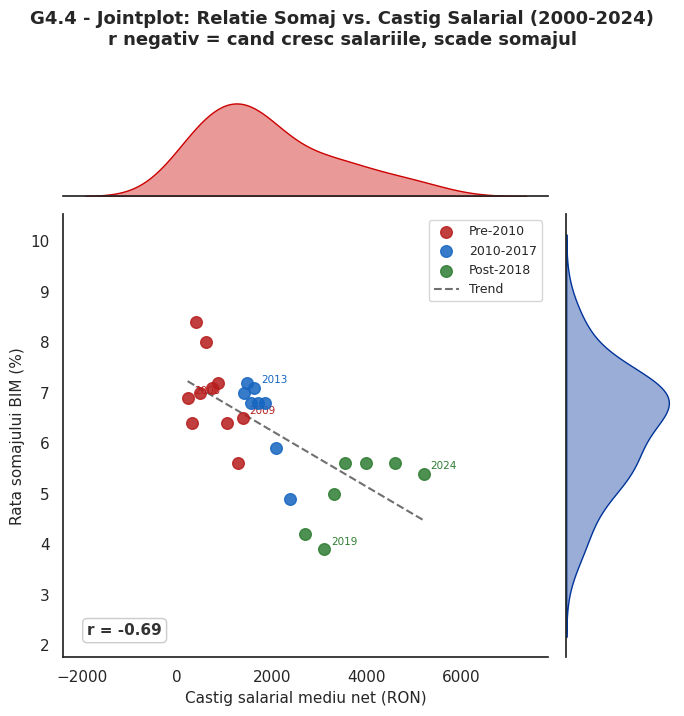

In [72]:
import numpy as np

# Merge somaj anual + castig anual
df_c_an = df_castig.copy()
df_c_an['an'] = df_c_an['data'].dt.year
df_c_an = df_c_an.groupby('an')['castig_net_total_ron'].mean().reset_index()

df_joint = df_somaj_an.merge(df_c_an, on='an')
df_joint.columns = ['an', 'somaj_pct', 'castig_ron']

# Coloram punctele dupa era
df_joint['era'] = df_joint['an'].apply(
    lambda x: 'Pre-2010' if x < 2010
    else ('2010-2017' if x < 2018 else 'Post-2018'))

culori_joint = {'Pre-2010': '#B71C1C', '2010-2017': '#1565C0', 'Post-2018': '#2E7D32'}

g = sns.JointGrid(data=df_joint, x='castig_ron', y='somaj_pct',
                  height=7, ratio=4)

# Scatter central cu culori per era
for era, culoare in culori_joint.items():
    subset = df_joint[df_joint['era'] == era]
    g.ax_joint.scatter(subset['castig_ron'], subset['somaj_pct'],
                       color=culoare, s=70, alpha=0.85,
                       label=era, zorder=5)

    # Eticheta an
    for _, row in subset.iterrows():
        if row['an'] in [2000, 2009, 2013, 2019, 2024]:
            g.ax_joint.annotate(str(int(row['an'])),
                               xy=(row['castig_ron'], row['somaj_pct']),
                               xytext=(5, 3), textcoords='offset points',
                               fontsize=7.5, color=culoare)

# Linie de regresie
z = np.polyfit(df_joint['castig_ron'], df_joint['somaj_pct'], 1)
p = np.poly1d(z)
x_reg = np.linspace(df_joint['castig_ron'].min(),
                    df_joint['castig_ron'].max(), 100)
g.ax_joint.plot(x_reg, p(x_reg), color='#333333',
                linewidth=1.5, linestyle='--', alpha=0.7,
                label='Trend')

corr = df_joint['castig_ron'].corr(df_joint['somaj_pct'])
g.ax_joint.text(0.05, 0.05, f'r = {corr:.2f}',
                transform=g.ax_joint.transAxes,
                fontsize=11, color='#333333', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                         facecolor='white', edgecolor='#cccccc'))

# Distributii marginale
sns.kdeplot(data=df_joint, x='castig_ron', ax=g.ax_marg_x,
            fill=True, color=CUL['ro'], alpha=0.4)
sns.kdeplot(data=df_joint, y='somaj_pct', ax=g.ax_marg_y,
            fill=True, color=CUL['ue'], alpha=0.4)

g.ax_joint.set_xlabel('Castig salarial mediu net (RON)', fontsize=11)
g.ax_joint.set_ylabel('Rata somajului BIM (%)', fontsize=11)
g.ax_joint.legend(fontsize=9, loc='upper right')

g.fig.suptitle('G4.4 - Jointplot: Relatie Somaj vs. Castig Salarial (2000-2024)\n'
               'r negativ = cand cresc salariile, scade somajul',
               fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 🏛️ Capitol 5 - Finanțe Publice

România a depășit limita Maastricht de -3% deficit bugetar în 7 din ultimii 10 ani. Datoria publică rămâne sub 60%, dar traiectoria e ascendentă. Randamentul obligațiunilor reflectă percepția de risc - în creștere față de media UE.


#### G5.1 - Deficit Bugetar: România vs. UE-27 (% PIB, 2000–2025)
**Tipul graficului:** Bare grupate + linie prag Maastricht (-3%)  
**Mesajul:** România a depășit limita de -3% repetat - și în 2024 a atins -9.3% PIB, cel mai mare din UE.


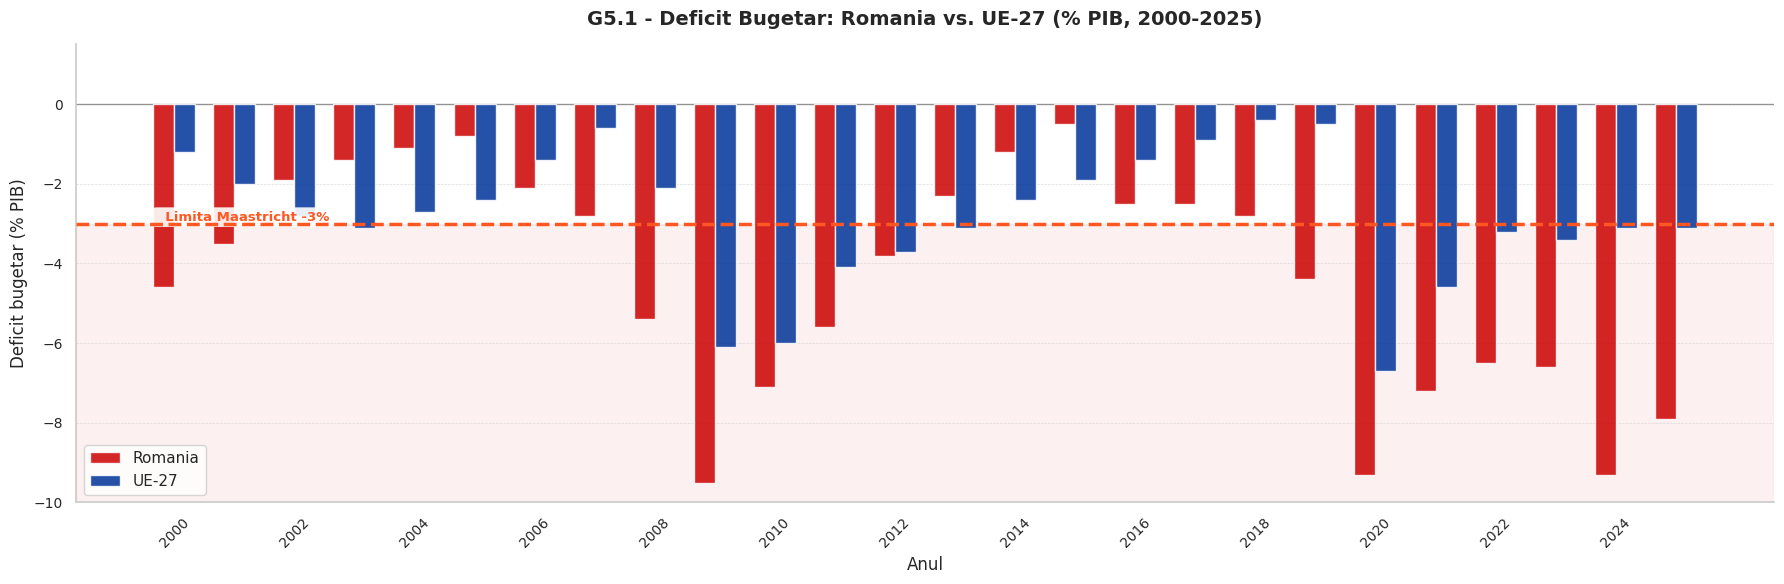

In [37]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_d = df_deficit.copy()
x = df_d['an'].values
width = 0.35

bars_ro = ax.bar(x - width/2, df_d['deficit_ro_pct'], width, label='Romania',
                 color=CUL['ro'], alpha=0.85, zorder=3)
bars_ue = ax.bar(x + width/2, df_d['deficit_ue_pct'], width, label='UE-27',
                 color=CUL['ue'], alpha=0.85, zorder=3)

# Zona de incalcare Maastricht (sub -3%) - fundal rosu pal
y_min = min(df_d['deficit_ro_pct'].min(), df_d['deficit_ue_pct'].min()) - 0.5
ax.axhspan(y_min, -3, alpha=0.06, color=CUL['ro'], zorder=0)

# Linia Maastricht mai groasa si mai vizibila
ax.axhline(y=-3, color='#FF5722', linewidth=2.5, linestyle='--', zorder=5)
ax.text(x[0] - 0.3, -3, '  Limita Maastricht -3%',
        ha='left', va='bottom', fontsize=9.5, color='#FF5722',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.9))

# Linie zero
ax.axhline(y=0, color='#555555', linewidth=1, alpha=0.6, zorder=2)

# Grid orizontal subtil
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('Deficit bugetar (% PIB)', fontsize=12)
ax.set_title('G5.1 - Deficit Bugetar: Romania vs. UE-27 (% PIB, 2000-2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=11, loc='lower left')
ax.set_xticks(x[::2])
ax.set_xticklabels(x[::2], rotation=45, fontsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(y_min, 1.5)

plt.tight_layout()
plt.show()

#### G5.2 - Datorie Publică: România vs. UE-27 (% PIB, 2000–2025)
**Tipul graficului:** Linie multi-serie cu prag la 60%  
**Mesajul:** România rămâne sub 60%, dar traiectoria e accelerată - de la 18% (2007) la 52% (2025).


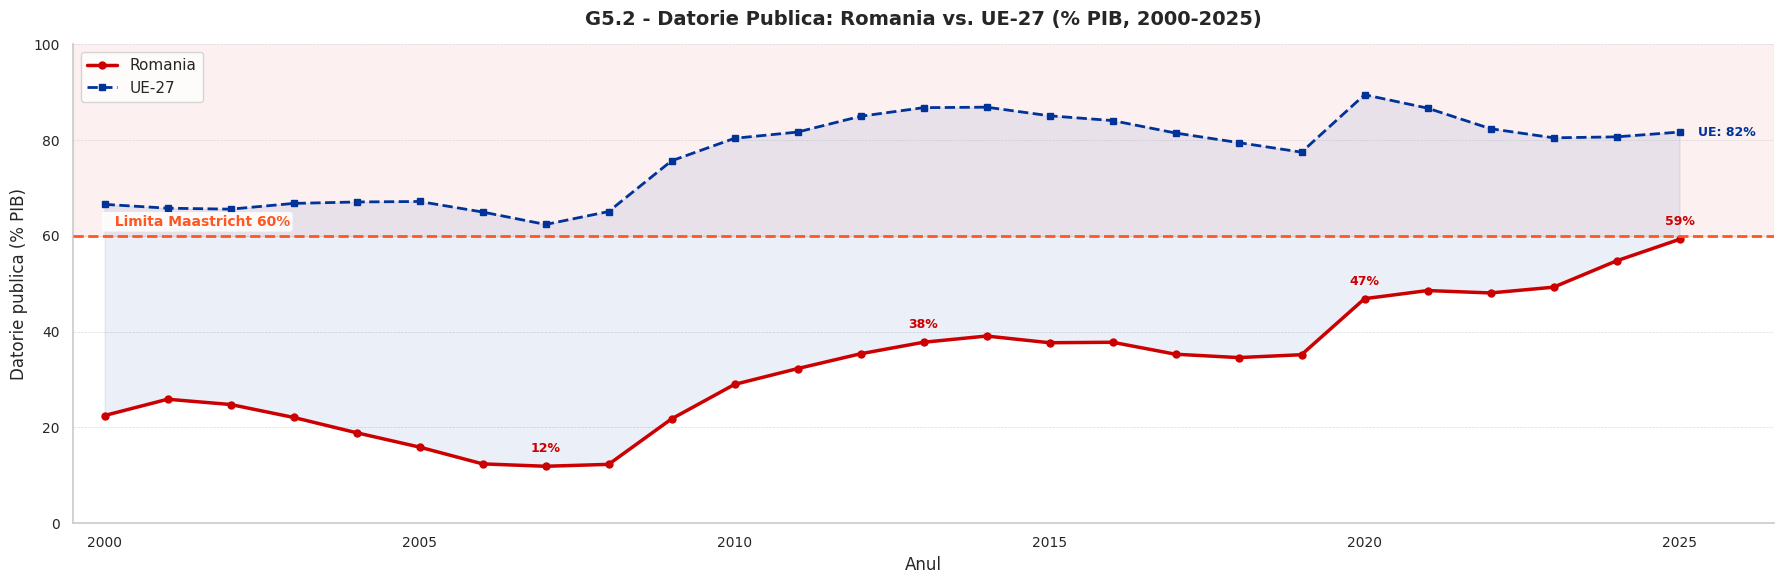

In [40]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_dat = df_datorie.copy()

# Zona de depasire Maastricht (peste 60%) - fundal rosu pal
ax.axhspan(60, 105, alpha=0.06, color=CUL['ro'], zorder=0)

# Grid orizontal subtil
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Fill intre cele doua linii - arata convergenta
ax.fill_between(df_dat['an'], df_dat['datorie_ro_pct'], df_dat['datorie_ue_pct'],
                alpha=0.08, color=CUL['ue'], label='_nolegend_')

ax.plot(df_dat['an'], df_dat['datorie_ro_pct'], color=CUL['ro'], linewidth=2.5,
        marker='o', markersize=5, label='Romania', zorder=4)
ax.plot(df_dat['an'], df_dat['datorie_ue_pct'], color=CUL['ue'], linewidth=2,
        linestyle='--', marker='s', markersize=4, label='UE-27', zorder=3)

# Linia Maastricht
ax.axhline(y=60, color='#FF5722', linewidth=2, linestyle='--', zorder=5)
ax.text(df_dat['an'].min(), 61.5, '  Limita Maastricht 60%',
        ha='left', va='bottom', fontsize=10, color='#FF5722', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# Etichete Romania la ani cheie
for an_ref in [2007, 2013, 2020, 2025]:
    val = df_dat[df_dat['an']==an_ref]['datorie_ro_pct'].values
    if len(val) > 0:
        ax.annotate(f'{val[0]:.0f}%', xy=(an_ref, val[0]),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color=CUL['ro'], fontweight='bold')

# Eticheta UE-27 la final
val_ue_last = df_dat['datorie_ue_pct'].iloc[-1]
ax.text(df_dat['an'].iloc[-1] + 0.3, val_ue_last,
        f"UE: {val_ue_last:.0f}%", fontsize=9, color=CUL['ue'],
        va='center', fontweight='bold')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('Datorie publica (% PIB)', fontsize=12)
ax.set_title('G5.2 - Datorie Publica: Romania vs. UE-27 (% PIB, 2000-2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(df_dat['an'].min() - 0.5, df_dat['an'].max() + 1.5)
ax.set_ylim(0, 100)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

#### G5.3 - Randament Obligațiuni Stat 10Y + Rezerve BNR (ax dual)
**Tipul graficului:** Linie randamente (stânga) + linie rezerve (dreapta)  
**Mesajul:** Spread-ul RO față de UE crește - semnalând percepție de risc în creștere. Rezervele BNR tampoanizează.


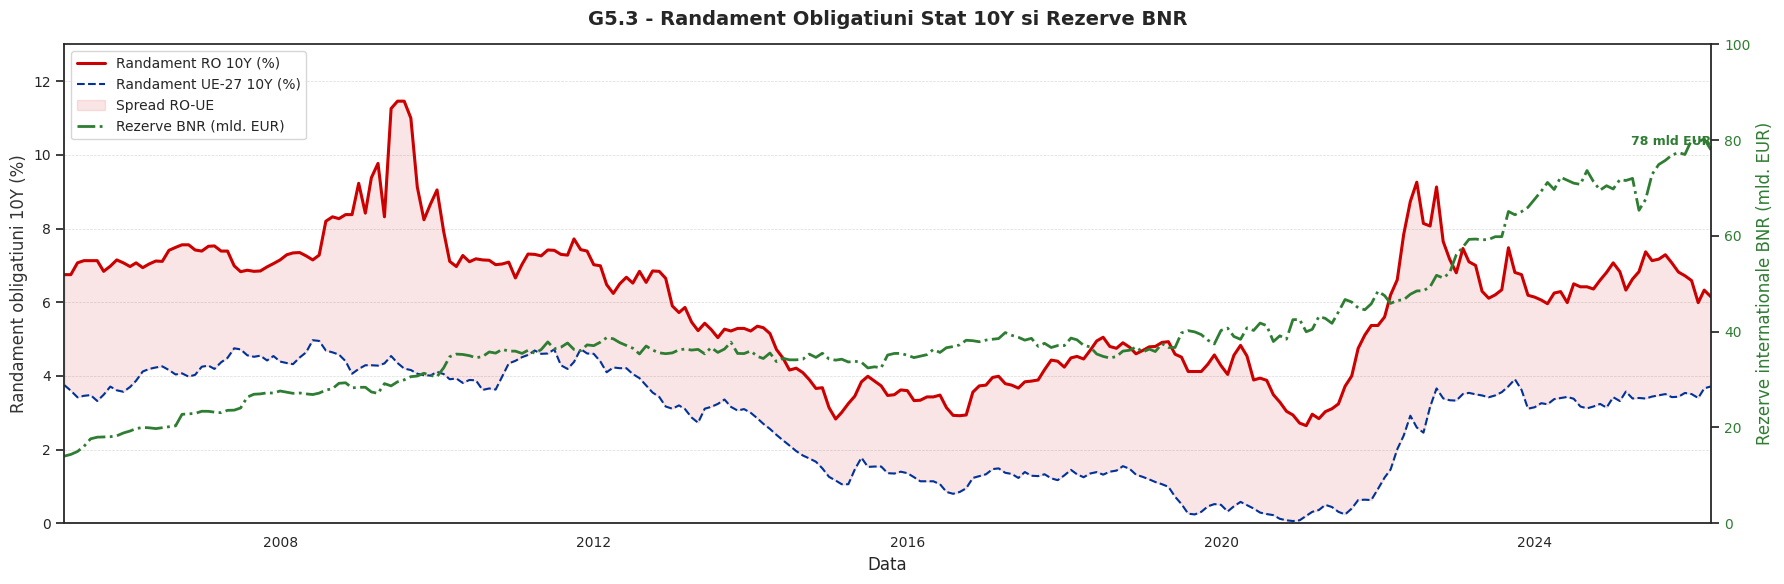

In [42]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_r = df_rand_rez.dropna(subset=['rand_ro_pct']).copy()

# Grid orizontal subtil doar pe ax1
ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)

ax1.plot(df_r['data'], df_r['rand_ro_pct'],
         color=CUL['ro'], linewidth=2.2, label='Randament RO 10Y (%)', zorder=4)
ax1.plot(df_r['data'], df_r['rand_ue_pct'],
         color=CUL['ue'], linewidth=1.5, linestyle='--',
         label='Randament UE-27 10Y (%)', zorder=3)

# Spread - mai subtil
ax1.fill_between(df_r['data'], df_r['rand_ro_pct'], df_r['rand_ue_pct'],
                 where=df_r['rand_ro_pct'] > df_r['rand_ue_pct'],
                 alpha=0.10, color=CUL['ro'], label='Spread RO-UE')

ax1.set_ylabel('Randament obligatiuni 10Y (%)', color='#333333', fontsize=12)
ax1.tick_params(axis='y', labelsize=10)
ax1.set_ylim(0, 13)

ax2 = ax1.twinx()
df_rez_plot = df_rand_rez.dropna(subset=['rezerve_mld_eur'])

# Rezerve - doar linia, fara fill
ax2.plot(df_rez_plot['data'], df_rez_plot['rezerve_mld_eur'],
         color=CUL['verde'], linewidth=2, linestyle='-.',
         label='Rezerve BNR (mld. EUR)', zorder=2)

# Eticheta finala pe linie
ax2.text(df_rez_plot['data'].iloc[-1], df_rez_plot['rezerve_mld_eur'].iloc[-1] + 1,
         f"{df_rez_plot['rezerve_mld_eur'].iloc[-1]:.0f} mld EUR",
         fontsize=9, color=CUL['verde'], fontweight='bold', ha='right')

ax2.set_ylabel('Rezerve internationale BNR (mld. EUR)', color=CUL['verde'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=CUL['verde'], labelsize=10)
ax2.yaxis.grid(False)
ax2.set_ylim(0, 100)

for spine in ['top']:
    ax1.spines[spine].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
ax1.set_xlabel('Data', fontsize=12)
ax1.set_title('G5.3 - Randament Obligatiuni Stat 10Y si Rezerve BNR',
              fontsize=14, fontweight='bold', pad=14)
ax1.set_xlim(df_r['data'].min(), df_r['data'].max())
ax1.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

#### G5.4 - România vs. UE pe 5 indicatori (2024)

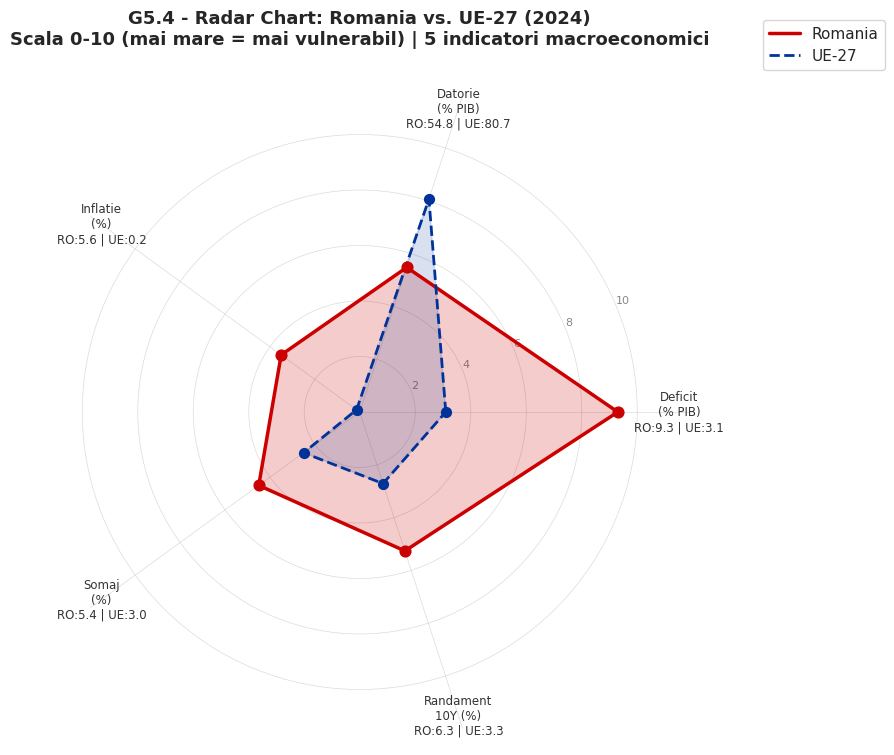

In [75]:
import numpy as np

fig, ax = plt.subplots(figsize=(9, 9),
                       subplot_kw=dict(polar=True))
sns.set(style='white')

# Cei 5 indicatori pentru 2024 (sau cel mai recent an disponibil)
indicatori = ['Deficit\n(% PIB)', 'Datorie\n(% PIB)', 'Inflatie\n(%)',
              'Somaj\n(%)', 'Randament\n10Y (%)']

def get_val(df, col, an):
    r = df[df['an'] == an][col].values
    return float(r[0]) if len(r) else None

an_ref = 2024

ro_vals_raw = [
    abs(get_val(df_deficit,  'deficit_ro_pct', an_ref) or 0),
    get_val(df_datorie,  'datorie_ro_pct', an_ref) or 0,
    get_val(df_inflatie, 'rata_inflatie_pct', an_ref) or 0,
    get_val(df_somaj_an, 'somaj_pct', an_ref) or 0,
    df_rand[df_rand['data'].dt.year == an_ref]['rand_ro_pct'].mean()
]

ue_vals_raw = [
    abs(get_val(df_deficit, 'deficit_ue_pct', an_ref) or 0),
    get_val(df_datorie, 'datorie_ue_pct', an_ref) or 0,
    get_val(df_hicp[df_hicp['data'].dt.year == an_ref],
            'hicp_ue', an_ref) if False else
        df_hicp[df_hicp['data'].dt.year == an_ref]['hicp_ue'].mean(),
    3.0,  # somaj UE aproximativ 2024
    df_rand[df_rand['data'].dt.year == an_ref]['rand_ue_pct'].mean()
]

# Normalizare 0-10 (mai mare = mai rau pentru toti indicatorii)
maxime = [10, 100, 16, 12, 12]

ro_norm = [min(v/m*10, 10) for v, m in zip(ro_vals_raw, maxime)]
ue_norm = [min(v/m*10, 10) for v, m in zip(ue_vals_raw, maxime)]

N = len(indicatori)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ro_norm += ro_norm[:1]
ue_norm += ue_norm[:1]

ax.plot(angles, ro_norm, color=CUL['ro'], linewidth=2.5,
        linestyle='-', label='Romania')
ax.fill(angles, ro_norm, color=CUL['ro'], alpha=0.2)

ax.plot(angles, ue_norm, color=CUL['ue'], linewidth=2,
        linestyle='--', label='UE-27')
ax.fill(angles, ue_norm, color=CUL['ue'], alpha=0.15)

# Puncte pe fiecare vertex
ax.scatter(angles[:-1], ro_norm[:-1], color=CUL['ro'], s=60, zorder=5)
ax.scatter(angles[:-1], ue_norm[:-1], color=CUL['ue'], s=50, zorder=5)

# Etichete cu valorile reale
for i, (angle, ind, rv, uv) in enumerate(
        zip(angles[:-1], indicatori, ro_vals_raw, ue_vals_raw)):
    ax.text(angle, 11.5, f'{ind}\nRO:{rv:.1f} | UE:{uv:.1f}',
            ha='center', va='center', fontsize=8.5,
            color='#333333')

ax.set_xticks(angles[:-1])
ax.set_xticklabels([''] * N)
ax.set_ylim(0, 12)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'],
                   fontsize=8, color='#888888')
ax.grid(color='#cccccc', linewidth=0.5, alpha=0.7)
ax.spines['polar'].set_visible(False)

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_title(f'G5.4 - Radar Chart: Romania vs. UE-27 ({an_ref})\n'
             'Scala 0-10 (mai mare = mai vulnerabil) | 5 indicatori macroeconomici',
             fontsize=13, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

#### G5.5 - Ani cu deficit peste limita Maastricht

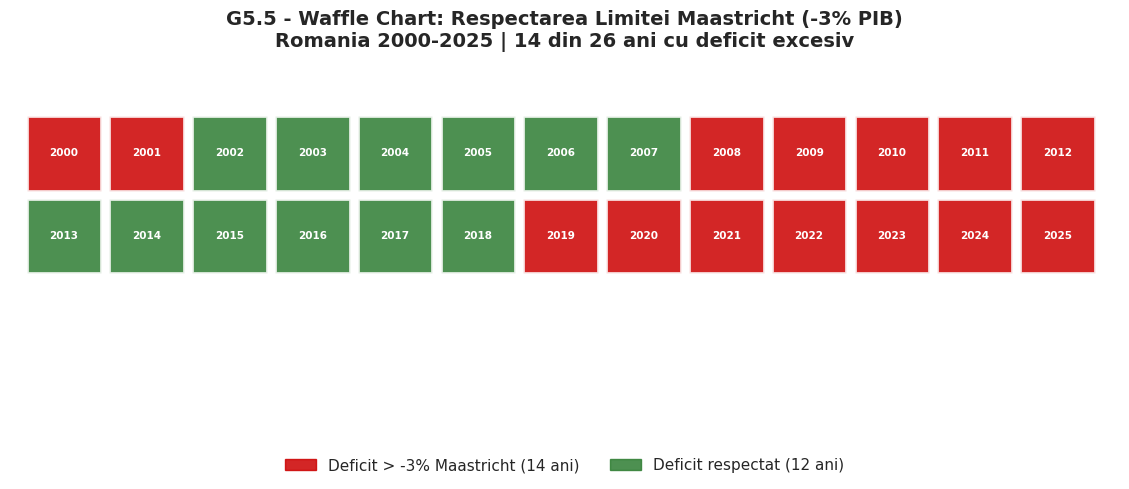

In [76]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.set(style='white')
ax.set_aspect('equal')
ax.axis('off')

ani_deficit = df_deficit.sort_values('an').copy()
total_ani = len(ani_deficit)
cols = 13

for idx, (_, row) in enumerate(ani_deficit.iterrows()):
    col = idx % cols
    lin = idx // cols
    depasit = row['deficit_ro_pct'] < -3
    culoare = CUL['ro'] if depasit else CUL['verde']
    an = int(row['an'])

    rect = plt.Rectangle((col, -lin), 0.9, 0.9,
                          facecolor=culoare, alpha=0.85,
                          edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(col + 0.45, -lin + 0.45, str(an),
            ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white')

ax.set_xlim(-0.2, cols + 0.2)
ax.set_ylim(-total_ani//cols - 1.2, 1.5)

ani_dep = (ani_deficit['deficit_ro_pct'] < -3).sum()
ani_ok  = total_ani - ani_dep

import matplotlib.patches as mpatches
p_r = mpatches.Patch(color=CUL['ro'],    alpha=0.85,
                     label=f'Deficit > -3% Maastricht ({ani_dep} ani)')
p_v = mpatches.Patch(color=CUL['verde'], alpha=0.85,
                     label=f'Deficit respectat ({ani_ok} ani)')
ax.legend(handles=[p_r, p_v], loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=11,
          ncol=2, frameon=False)

ax.set_title(f'G5.5 - Waffle Chart: Respectarea Limitei Maastricht (-3% PIB)\n'
             f'Romania 2000-2025 | {ani_dep} din {total_ani} ani cu deficit excesiv',
             fontsize=14, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()

---
### 📊 Capitol 6 - Piața de Capital și Clima Economică

BVB a crescut de ~6× în 15 ani. PMI-ul Eurozonei anticipează ciclul economic global - România e sincronizată cu acesta.


#### G6.1 - Indicele BET (2010–2026) cu crize adnotate
**Tipul graficului:** Linie cu adnotări și fill  
**Mesajul:** BET a pierdut 50% în COVID, a recuperat în 18 luni și a atins maximul istoric în 2026.


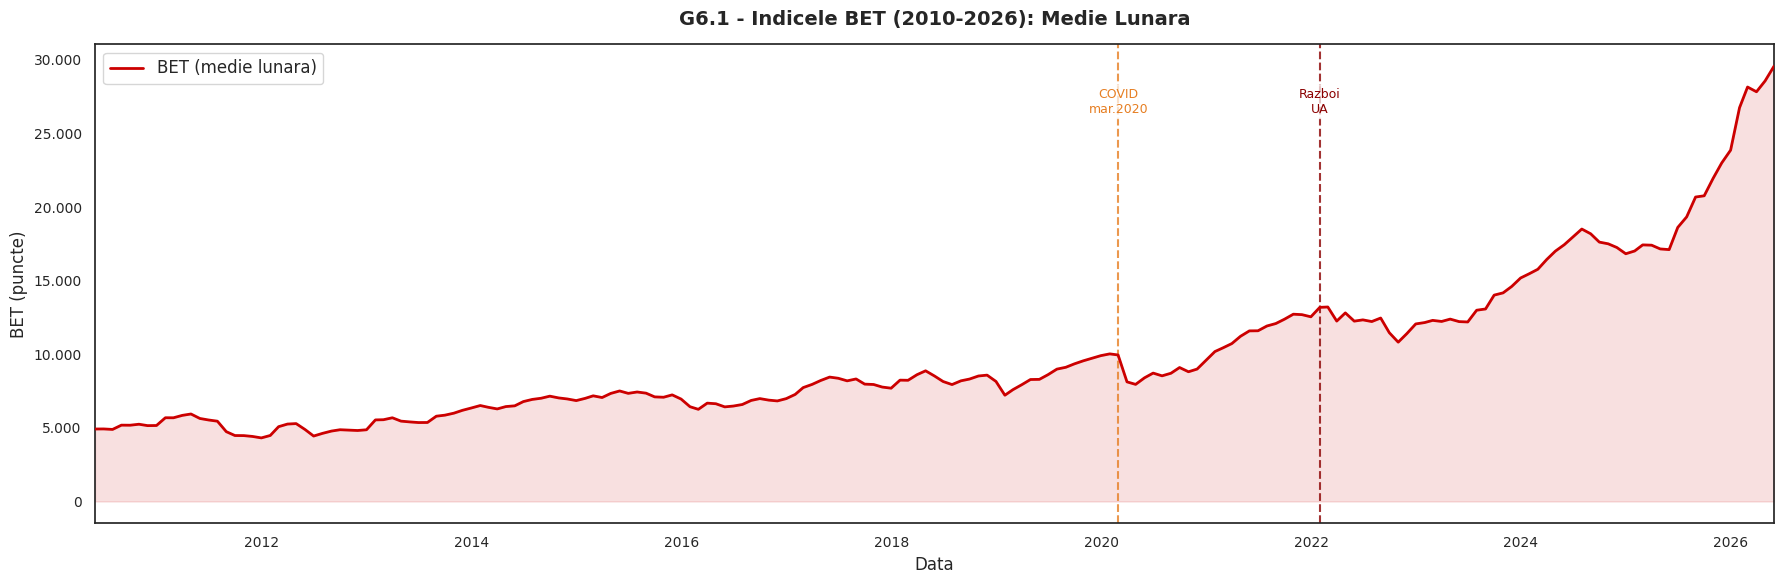

In [77]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_b = df_bet_lunar.copy()
ax.plot(df_b['data'], df_b['bet_pret'], color=CUL['ro'], linewidth=2, zorder=4, label='BET (medie lunara)')
ax.fill_between(df_b['data'], df_b['bet_pret'], alpha=0.12, color=CUL['ro'])

# Marcare simpla cu linii verticale si text - fara sageti
events = [
    (pd.Timestamp('2020-03'), 'COVID\nmar.2020', CUL['portoc']),
    (pd.Timestamp('2022-02'), 'Razboi\nUA', '#8B0000'),
]
for data_ev, label, culoare in events:
    ax.axvline(x=data_ev, color=culoare, linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(data_ev, df_b['bet_pret'].max() * 0.95, label,
            ha='center', va='top', fontsize=9, color=culoare,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('BET (puncte)', fontsize=12)
ax.set_title('G6.1 - Indicele BET (2010-2026): Medie Lunara', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))
ax.set_xlim(df_b['data'].min(), df_b['data'].max())
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

#### G6.2 - Capitalizare BVB anuală (mld. RON) + PMI Eurozonă (ax dual)
**Tipul graficului:** Bare capitalizare + linie PMI pe ax dual  
**Mesajul:** Capitalizarea BVB crește accelerat după 2020 - parțial corelată cu PMI-ul Eurozonei.


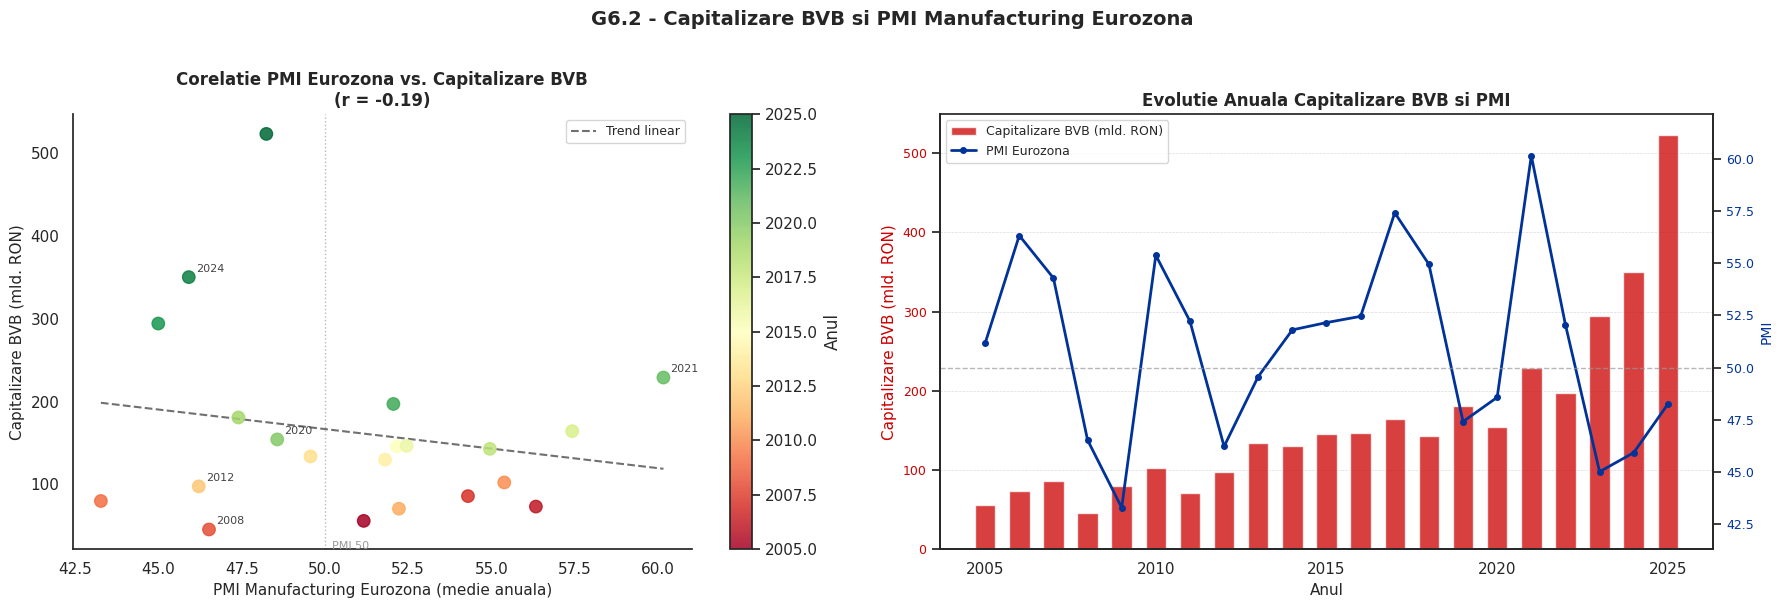

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set(style='white')

df_bp = df_bvb_pmi.dropna(subset=['capitalizare_mld_ron','pmi_eurozona']).copy()

# --- Stânga: Scatter PMI vs Capitalizare cu regresie ---
ax1 = axes[0]

scatter = ax1.scatter(df_bp['pmi_eurozona'], df_bp['capitalizare_mld_ron'],
                      c=df_bp['an'], cmap='RdYlGn', s=80, zorder=5, alpha=0.85)

# Linie regresie
import numpy as np
z = np.polyfit(df_bp['pmi_eurozona'], df_bp['capitalizare_mld_ron'], 1)
p = np.poly1d(z)
x_reg = np.linspace(df_bp['pmi_eurozona'].min(), df_bp['pmi_eurozona'].max(), 100)
ax1.plot(x_reg, p(x_reg), color='#333333', linewidth=1.5,
         linestyle='--', alpha=0.7, label='Trend linear')

# Etichete ani
for _, row in df_bp[df_bp['an'].isin([2008,2012,2020,2021,2024])].iterrows():
    ax1.annotate(str(int(row['an'])),
                 xy=(row['pmi_eurozona'], row['capitalizare_mld_ron']),
                 xytext=(5, 4), textcoords='offset points',
                 fontsize=8, color='#444444')

plt.colorbar(scatter, ax=ax1, label='Anul')
ax1.axvline(x=50, color='#999999', linewidth=1, linestyle=':', alpha=0.7)
ax1.text(50.2, ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 5,
         'PMI 50', fontsize=8, color='#999999')

# CalculeR²
from numpy.polynomial.polynomial import polyfit as npfit
corr = df_bp['pmi_eurozona'].corr(df_bp['capitalizare_mld_ron'])
ax1.set_title(f'Corelatie PMI Eurozona vs. Capitalizare BVB\n(r = {corr:.2f})',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('PMI Manufacturing Eurozona (medie anuala)', fontsize=11)
ax1.set_ylabel('Capitalizare BVB (mld. RON)', fontsize=11)
ax1.legend(fontsize=9)
for spine in ['top','right']:
    ax1.spines[spine].set_visible(False)

# --- Dreapta: Evolutie anuala (line simplu) ---
ax2 = axes[1]
ax2.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax2.xaxis.grid(False)
ax2.set_axisbelow(True)

ax2.bar(df_bp['an'], df_bp['capitalizare_mld_ron'],
        color=CUL['ro'], alpha=0.75, width=0.6, label='Capitalizare BVB (mld. RON)')
ax2_twin = ax2.twinx()
ax2_twin.plot(df_bp['an'], df_bp['pmi_eurozona'],
              color=CUL['ue'], linewidth=2, marker='o', markersize=4,
              label='PMI Eurozona')
ax2_twin.axhline(y=50, color='#999999', linewidth=1, linestyle='--', alpha=0.7)
ax2_twin.set_ylim(df_bp['pmi_eurozona'].min()-2, df_bp['pmi_eurozona'].max()+2)
ax2_twin.set_ylabel('PMI', color=CUL['ue'], fontsize=10)
ax2_twin.tick_params(axis='y', labelcolor=CUL['ue'], labelsize=9)
ax2_twin.yaxis.grid(False)

ax2.set_xlabel('Anul', fontsize=11)
ax2.set_ylabel('Capitalizare BVB (mld. RON)', color=CUL['ro'], fontsize=11)
ax2.tick_params(axis='y', labelcolor=CUL['ro'], labelsize=9)
ax2.set_title('Evolutie Anuala Capitalizare BVB si PMI', fontsize=12, fontweight='bold')
for spine in ['top']:
    ax2.spines[spine].set_visible(False)

lines1, l1 = ax2.get_legend_handles_labels()
lines2, l2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, l1+l2, fontsize=9, loc='upper left')

fig.suptitle('G6.2 - Capitalizare BVB si PMI Manufacturing Eurozona',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
### 👥 Capitol 7 - Demografie: Bomba cu Ceas

Convergența economică se construiește pe un fundament care se surpă. România pierde simultan prin natalitate scăzută și emigrație masivă - un declin demografic structural.


#### G7.1 - Piramida Vârstelor: 2003 vs. 2024
**Tipul graficului:** Barh back-to-back (masculin stânga, feminin dreapta)  
**Mesajul:** Piramida s-a transformat dintr-o formă clasică în una de 'urnă' - baza s-a îngust semnificativ, vârful s-a lărgit.


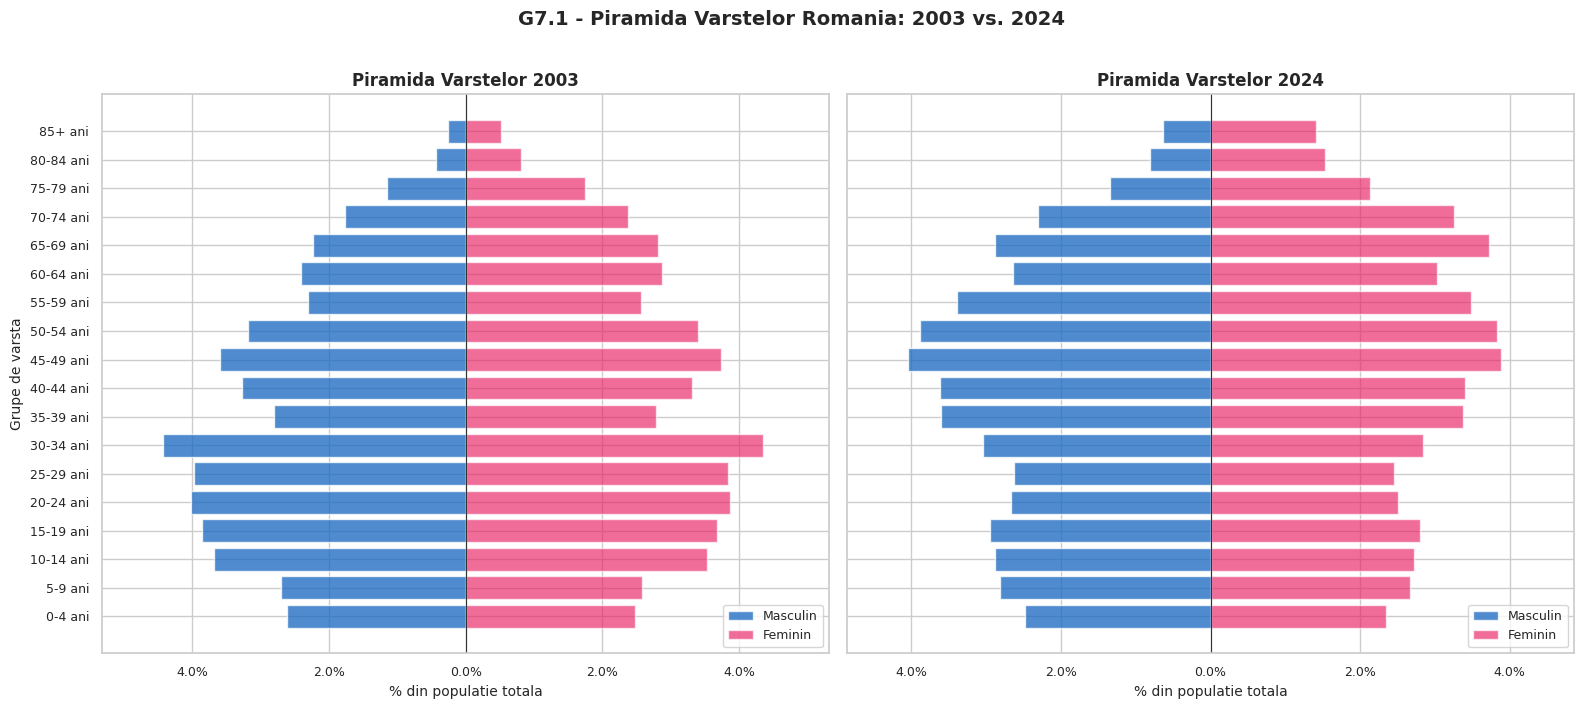

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sns.set(style='white')

for idx, an_ref in enumerate([2003, 2024]):
    ax = axes[idx]
    df_an = df_pop[df_pop['an'] == an_ref].copy()

    total = df_an['populatie'].sum()
    grupe_ordonate = [g for g in ORDINE_GRUPE if g in df_an['grupa_varsta'].values]

    masc_vals, fem_vals, grupe_label = [], [], []
    for g in grupe_ordonate:
        m_val = df_an[(df_an['grupa_varsta']==g) & (df_an['sex']=='Masculin')]['populatie'].sum()
        f_val = df_an[(df_an['grupa_varsta']==g) & (df_an['sex']=='Feminin')]['populatie'].sum()
        masc_vals.append(-m_val / total * 100)
        fem_vals.append(f_val / total * 100)
        g_label = g.replace('sipeste','+').replace('_','-')
        grupe_label.append(g_label + ' ani')

    ax.barh(grupe_label, masc_vals, color='#1565C0', alpha=0.75, label='Masculin')
    ax.barh(grupe_label, fem_vals, color='#E91E63', alpha=0.65, label='Feminin')
    ax.axvline(x=0, color='#333333', linewidth=0.8)

    max_val = max(abs(min(masc_vals)), max(fem_vals)) * 1.2
    ax.set_xlim(-max_val, max_val)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(x):.1f}%'))
    ax.set_title(f'Piramida Varstelor {an_ref}', fontsize=12, fontweight='bold')
    ax.set_xlabel('% din populatie totala', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    ax.legend(fontsize=9, loc='lower right')

    if idx == 0:
        ax.set_ylabel('Grupe de varsta', fontsize=10)

fig.suptitle('G7.1 - Piramida Varstelor Romania: 2003 vs. 2024',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### G7.2 - Rata Natalității (‰) și Migrație Netă anuală (ax dual)
**Tipul graficului:** Linie ax dual  
**Mesajul:** Natalitatea a scăzut de la 10.3‰ (2000) la 7.2‰ (2024). Migrația netă a intrat în teritoriu pozitiv abia din 2022 - posibil influx din Ucraina.


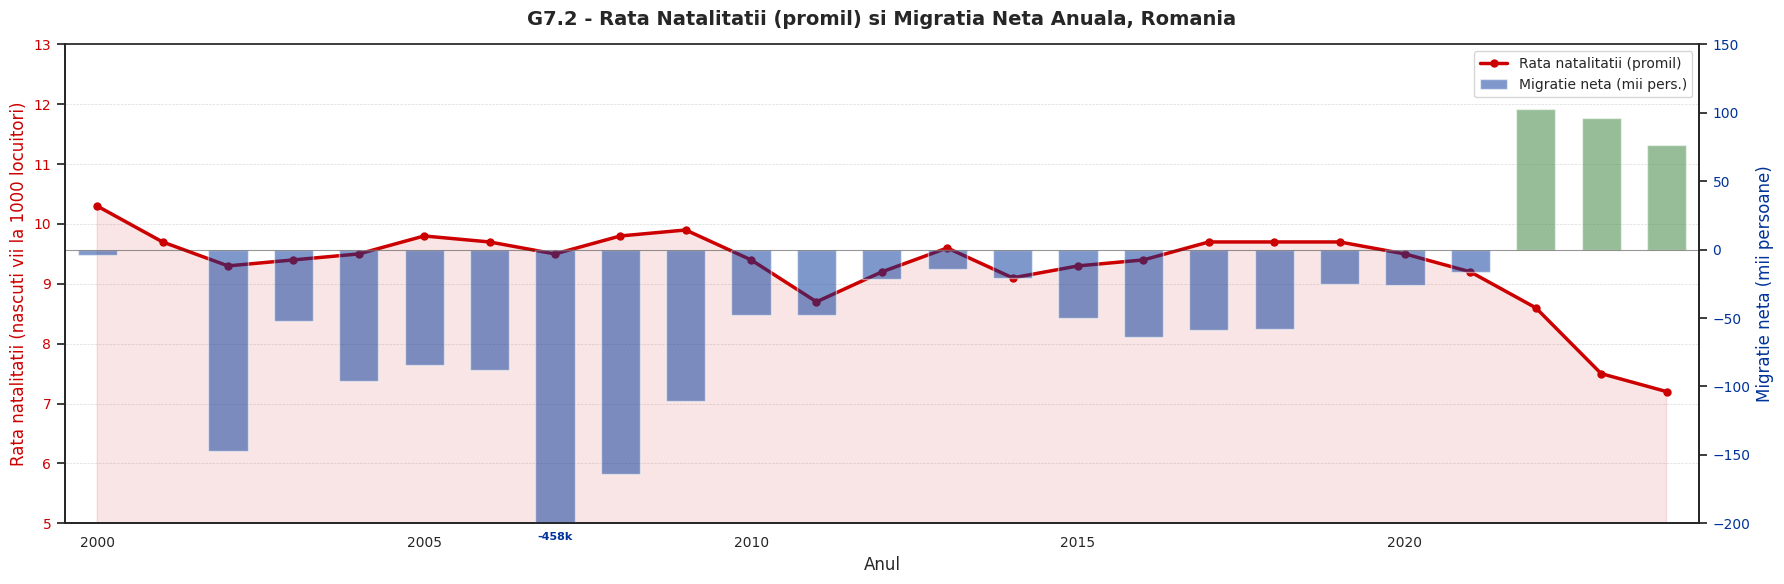

In [62]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_dm = df_demo.dropna(subset=['rata_natalitate_promil']).copy()
df_mig_clean = df_dm[df_dm['an'] != 2001].dropna(subset=['migratie_neta'])

ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)

ax1.plot(df_dm['an'], df_dm['rata_natalitate_promil'],
         color=CUL['ro'], linewidth=2.5, marker='o', markersize=5,
         label='Rata natalitatii (promil)', zorder=4)
ax1.fill_between(df_dm['an'], df_dm['rata_natalitate_promil'],
                 alpha=0.10, color=CUL['ro'])
ax1.set_ylabel('Rata natalitatii (nascuti vii la 1000 locuitori)',
               color=CUL['ro'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=CUL['ro'], labelsize=10)
ax1.set_ylim(5, 13)

ax2 = ax1.twinx()

mig_vals = df_mig_clean['migratie_neta'] / 1000
culori_mig = [CUL['verde'] if v > 0 else CUL['ue'] for v in df_mig_clean['migratie_neta']]

# Clip valorile pentru afisare, pastrandu-le reale in date
mig_clip = mig_vals.clip(lower=-200)
ax2.bar(df_mig_clean['an'], mig_clip,
        color=culori_mig, alpha=0.50, width=0.6,
        label='Migratie neta (mii pers.)', zorder=2)

# Annotam barele taiate cu valoarea reala
for an, val_real, val_clip in zip(df_mig_clean['an'], mig_vals, mig_clip):
    if val_real < -200:
        ax2.annotate(f'{val_real:.0f}k',
                     xy=(an, -200),
                     xytext=(0, -12), textcoords='offset points',
                     ha='center', fontsize=8, color=CUL['ue'],
                     fontweight='bold')

ax2.axhline(y=0, color='#333333', linewidth=0.8, alpha=0.5)
ax2.set_ylabel('Migratie neta (mii persoane)', color=CUL['ue'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=CUL['ue'], labelsize=10)
ax2.set_ylim(-200, 150)
ax2.yaxis.grid(False)

for spine in ['top']:
    ax1.spines[spine].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)
ax1.set_xlabel('Anul', fontsize=12)
ax1.set_title('G7.2 - Rata Natalitatii (promil) si Migratia Neta Anuala, Romania',
              fontsize=14, fontweight='bold', pad=14)
ax1.set_xlim(df_dm['an'].min() - 0.5, df_dm['an'].max() + 0.5)
ax1.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

#### G7.3 - Structura populației pe grupe de vârstă: 2003 vs. 2024

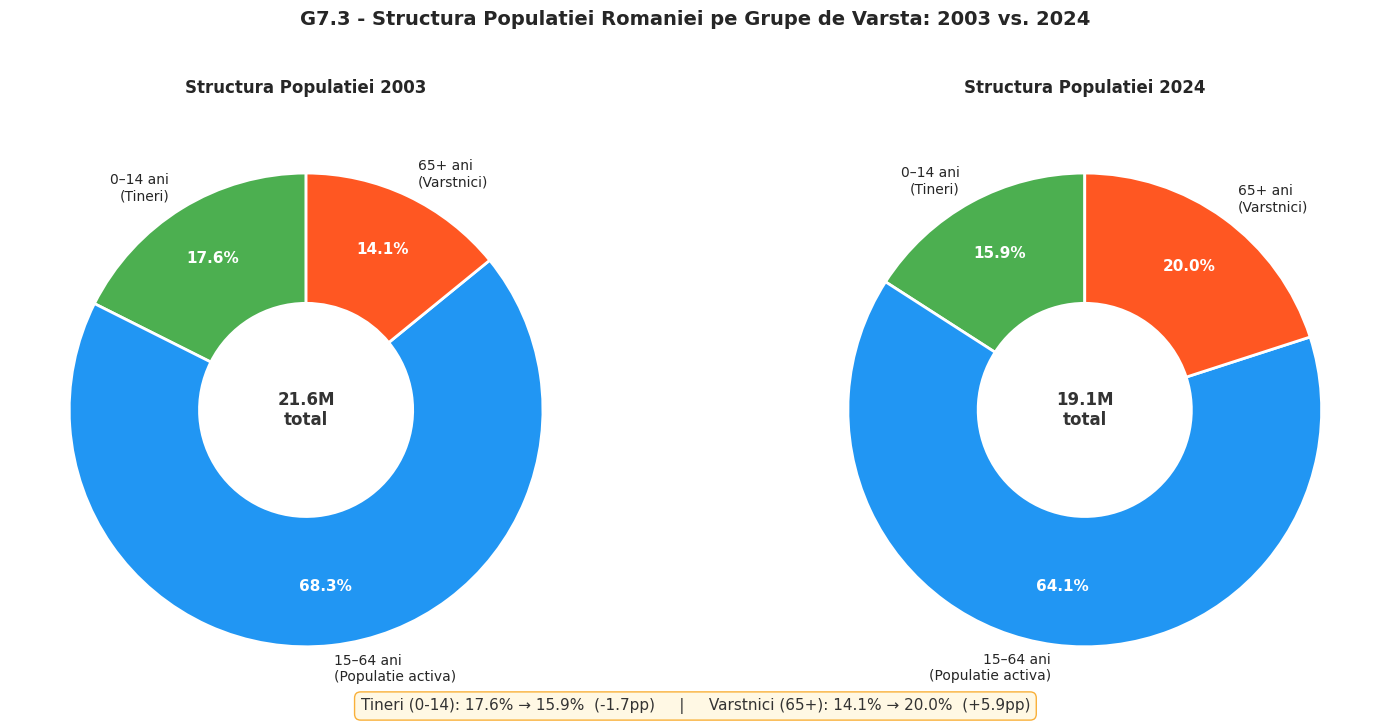

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set(style='white')

def grupeaza_varste(df_pop, an):
    df_an = df_pop[df_pop['an'] == an].copy()
    total = df_an['populatie'].sum()

    tineri = df_an[df_an['grupa_varsta'].isin(
        ['0-4','5-9','10-14'])]['populatie'].sum()
    activi = df_an[df_an['grupa_varsta'].isin(
        ['15-19','20-24','25-29','30-34','35-39',
         '40-44','45-49','50-54','55-59','60-64'])]['populatie'].sum()
    varstnici = df_an[df_an['grupa_varsta'].isin(
        ['65-69','70-74','75-79','80-84','85sipeste'])]['populatie'].sum()

    return [tineri/total*100, activi/total*100, varstnici/total*100]

culori_pie = ['#4CAF50', '#2196F3', '#FF5722']
etichete   = ['0–14 ani\n(Tineri)', '15–64 ani\n(Populatie activa)', '65+ ani\n(Varstnici)']

for idx, an_ref in enumerate([2003, 2024]):
    ax = axes[idx]
    valori = grupeaza_varste(df_pop, an_ref)

    wedges, texts, autotexts = ax.pie(
        valori,
        labels=etichete,
        colors=culori_pie,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.75,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
        textprops=dict(fontsize=10)
    )

    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
        autotext.set_color('white')

    # FIX: eliminat // 2
    pop_total = df_pop[df_pop['an']==an_ref]['populatie'].sum()
    ax.text(0, 0, f'{pop_total/1e6:.1f}M\ntotal',
            ha='center', va='center', fontsize=12,
            fontweight='bold', color='#333333')

    ax.set_title(f'Structura Populatiei {an_ref}',
                 fontsize=12, fontweight='bold', pad=15)

val_2003 = grupeaza_varste(df_pop, 2003)
val_2024 = grupeaza_varste(df_pop, 2024)
delta_tineri    = val_2024[0] - val_2003[0]
delta_varstnici = val_2024[2] - val_2003[2]

fig.text(0.5, 0.02,
         f'Tineri (0-14): {val_2003[0]:.1f}% → {val_2024[0]:.1f}%  '
         f'({delta_tineri:+.1f}pp)     |     '
         f'Varstnici (65+): {val_2003[2]:.1f}% → {val_2024[2]:.1f}%  '
         f'({delta_varstnici:+.1f}pp)',
         ha='center', fontsize=11, color='#333333',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8E1',
                   edgecolor='#F9A825', alpha=0.9))

fig.suptitle('G7.3 - Structura Populatiei Romaniei pe Grupe de Varsta: 2003 vs. 2024',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 📌 PUNCTUL 4 - Dashboard Interactiv cu `ipywidgets` *(2p)*

Dashboard-ul permite explorarea a 6 indicatori macroeconomici cu control complet al perioadei, tipului de afișare și evidențierii erelor istorice.

**Controale disponibile:**
- `Dropdown` - Selectează indicatorul din 6 opțiuni
- `IntRangeSlider` - Interval de ani
- `RadioButtons` - Valori absolute vs. variație anuală (YoY)
- `ToggleButton` - Afișează / ascunde erele istorice
- `Button` + `Output` - Generează graficul


In [49]:
# ── Configurare dashboard ────────────────────────────────────────
INDICATORI = {
    'Rata Inflației Anuale (%)': {
        'df': 'inflatie_anuala', 'col': 'rata_inflatie_pct',
        'xcol': 'an', 'ylabel': 'Rata inflației (%)',
        'tip': 'anual', 'culoare': CUL['ro']
    },
    'EUR/RON - Curs Zilnic': {
        'df': 'curs_valutar', 'col': 'eur_ron',
        'xcol': 'data', 'ylabel': 'EUR/RON',
        'tip': 'zilnic', 'culoare': CUL['ro']
    },
    'Deficit Bugetar România (% PIB)': {
        'df': 'deficit_bugetar', 'col': 'deficit_ro_pct',
        'xcol': 'an', 'ylabel': 'Deficit (% PIB)',
        'tip': 'anual', 'culoare': CUL['rosu']
    },
    'Datorie Publică România (% PIB)': {
        'df': 'datorie_publica', 'col': 'datorie_ro_pct',
        'xcol': 'an', 'ylabel': 'Datorie (% PIB)',
        'tip': 'anual', 'culoare': CUL['portoc']
    },
    'Randament Obligațiuni 10Y România (%)': {
        'df': 'randament_10y', 'col': 'rand_ro_pct',
        'xcol': 'data', 'ylabel': 'Randament 10Y (%)',
        'tip': 'lunar', 'culoare': CUL['ue']
    },
    'PMI Manufacturing Eurozonă': {
        'df': 'pmi_lunar', 'col': 'pmi_eurozona',
        'xcol': 'data', 'ylabel': 'PMI (indice)',
        'tip': 'lunar', 'culoare': CUL['gri']
    },
}

# Map nume df → variabilă Python
DF_MAP = {
    'inflatie_anuala': df_inflatie,
    'curs_valutar':    df_curs,
    'deficit_bugetar': df_deficit,
    'datorie_publica': df_datorie,
    'randament_10y':   df_rand,
    'pmi_lunar':       df_pmi,
}

print("✓ Dashboard configurat cu", len(INDICATORI), "indicatori.")

✓ Dashboard configurat cu 6 indicatori.


In [50]:
# ── Construcție widget-uri ───────────────────────────────────────
st = {'description_width': 'initial'}
layout_w = pyw.Layout(width='420px')
layout_m = pyw.Layout(width='250px')

w_indicator = pyw.Dropdown(
    options=list(INDICATORI.keys()),
    description='📊 Indicator:',
    style=st, layout=layout_w
)

w_interval = pyw.IntRangeSlider(
    value=[2005, 2025],
    min=2000, max=2026, step=1,
    description='📅 Interval ani:',
    continuous_update=False,
    style=st, layout=layout_w
)

w_tip = pyw.RadioButtons(
    options=['Valori absolute', 'Variație YoY (%)'],
    description='📈 Tip afișare:',
    style=st, layout=layout_m
)

w_ere = pyw.ToggleButton(
    value=True,
    description='Afișează ere istorice',
    button_style='info',
    icon='check',
    layout=pyw.Layout(width='200px')
)

w_btn = pyw.Button(
    description='🔄 Generează grafic',
    button_style='primary',
    layout=pyw.Layout(width='200px')
)

w_err = pyw.Label(value='', style={'text_color': 'red'})
w_out = pyw.Output(layout={'border': '1px solid #e0e0e0', 'padding': '8px'})

# ── Funcție de afișare ───────────────────────────────────────────
def afisare_grafic(b=None):
    w_err.value = ''
    with w_out:
        w_out.clear_output(wait=True)

        cfg = INDICATORI[w_indicator.value]
        df_base = DF_MAP[cfg['df']].copy()
        xcol = cfg['xcol']
        col  = cfg['col']
        an_i, an_f = w_interval.value

        # Filtrare perioadă
        if xcol == 'an':
            df_f = df_base[(df_base['an'] >= an_i) & (df_base['an'] <= an_f)].dropna(subset=[col])
            x_vals = df_f['an']
        else:
            if xcol == 'data' and df_base[xcol].dtype == 'object':
                df_base[xcol] = pd.to_datetime(df_base[xcol])
            df_f = df_base[
                (df_base[xcol].dt.year >= an_i) & (df_base[xcol].dt.year <= an_f)
            ].dropna(subset=[col])
            x_vals = df_f[xcol]

        if len(df_f) < 2:
            w_err.value = '⚠ Date insuficiente pentru perioada selectată.'
            return

        y_vals = df_f[col].copy()
        ylabel = cfg['ylabel']

        # Variație YoY
        if w_tip.value == 'Variație YoY (%)':
            if xcol == 'an':
                y_vals = y_vals.pct_change() * 100
            else:
                y_vals = y_vals.pct_change(12) * 100
            ylabel = 'Variație anuală (%)'

        # Grafic
        fig, ax = plt.subplots(figsize=(15, 5))
        sns.set(style='whitegrid')

        ax.plot(x_vals, y_vals, color=cfg['culoare'], linewidth=2, zorder=4)
        ax.fill_between(x_vals, y_vals, alpha=0.12, color=cfg['culoare'])

        # Ere istorice
        if w_ere.value and xcol == 'an':
            for start, end, culoare, label in ERE:
                if end >= an_i and start <= an_f:
                    ax.axvspan(max(start, an_i), min(end, an_f), alpha=0.2, color=culoare, zorder=0)
                    mid = (max(start, an_i) + min(end, an_f)) / 2
                    ax.text(mid, ax.get_ylim()[1], label, ha='center', va='top',
                            fontsize=7, color='#666666', style='italic')

        # Linie zero
        if y_vals.min() < 0 < y_vals.max():
            ax.axhline(y=0, color='#333333', linewidth=0.8, linestyle='-', alpha=0.5)

        ax.set_xlabel('Perioada', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{w_indicator.value} ({an_i}–{an_f})', fontsize=13, fontweight='bold', pad=12)

        # Statistici în titlu secundar
        ax.set_xlabel(f'Min: {y_vals.min():.2f} | Max: {y_vals.max():.2f} | Medie: {y_vals.mean():.2f}', fontsize=9)

        plt.tight_layout()
        plt.show()

w_btn.on_click(afisare_grafic)
w_indicator.observe(afisare_grafic, names='value')

# ── Layout dashboard ──────────────────────────────────────────────
rand1 = pyw.HBox([w_indicator])
rand2 = pyw.HBox([w_interval])
rand3 = pyw.HBox([w_tip, pyw.VBox([w_ere, w_btn])])
rand4 = pyw.HBox([w_err])

dashboard = pyw.VBox([
    pyw.HTML('<h3 style="color:#CC0000">📊 Dashboard Macroeconomic România</h3>'),
    rand1, rand2, rand3, rand4, w_out
])
display(dashboard)
afisare_grafic()

## 📌 PUNCTUL 5 — Concluzii și Interpretări *(1.5p)*

### 5.1 Sinteza celor 4 acte narative

**Actul I (2000–2007) — Tranzitia:** Romania a demarat cu inflatie de 45.7% si un PIB sub 50 mld. USD.
Aderarea la UE in 2007 a declansat convergenta accelerata, dar si dependenta de capitaluri externe.

**Actul II (2007–2012) — Boom si criza:** Deficitul bugetar a explodat la -9.5% din PIB in 2009 — cel
mai mare din UE la acel moment. EUR/RON a sarit de la 3.1 la 4.2 in 6 luni. Romania a trait criza
mai dur decat media europeana, cu PIB-ul prabusindu-se cu ~7% in 2009.

**Actul III (2012–2021) — Consolidare fragila:** Crestere economica reluata, salarii in expansiune
accelerata (+400% in 10 ani), BET pe trend ascendent. Insa deficitul structural a reapărut din 2016
pe fondul majărilor salariale in sectorul public neacoperite de venituri fiscale.

**Actul IV (2021–2026) — Presiune maxima:** Inflatie record 13.8% in 2022, dobanda BNR la 7%,
deficit bugetar -9.3% din PIB in 2024 — cel mai mare din UE. BVB atinge 30.000 puncte,
iar rezervele BNR ating 80 mld. EUR — singurul tampon credibil.

---

### 5.2 Top 7 Insights derivate direct din grafice

**1. Convergenta PIB — reala, dar asimetrica** *(G1.2)*
Romania a ajuns de la 34% din media Euro Area in 2000 la ~75% in 2025 (indice volum).
Insa graficul trimestrial arata ca Romania coboara mai abrupt in crize decat urca in perioade de crestere — semn de economie prociclic, nu rezilienta.

**2. Dezinflatia — cea mai rapida din Europa Centrala** *(G2.1)*
De la 45.7% in 2000 la deflatie (-1.5%) in 2016, in doar 16 ani. Heatmap-ul HICP *(G2.2)* reveleaza
ceva mai subtil: lunile iulie-august au sistematic valorile negative (efectul sezonier agricol),
iar 2022 a rupt orice pattern — fiecare luna a anului a inregistrat inflatie pozitiva semnificativa.

**3. EUR/RON — ancora artificialā** *(G3.1)*
In timp ce EUR/HUF a crescut cu ~45% si EUR/PLN cu ~17% fata de baza din 2005,
EUR/RON a crescut cu doar ~17% — dar cu volatilitate aproape zero comparativ.
Aceasta stabilitate exceptionala are un pret: BNR consuma rezerve pentru a o mentine.

**4. Piata muncii — transformare structurala** *(G4.1, G4.2, G4.3)*
Somajul a scazut de la 10% (2001) la 3.9% (2019) — partial prin creare de locuri de munca,
partial prin emigratia a 3-4 milioane de romani. Scatter-ul salarial *(G4.3)* arata o
accelerare non-lineara dupa 2016: trendul linear nu mai captureaza dinamica — cresterea
salariului minim prin decizii politice a decuplat evolutia salariala de productivitate.

**5. Deficitul — problema structurala, nu conjuncturala** *(G5.1)*
Din cei 26 de ani analizati, Romania a respectat limita Maastricht de -3% in doar 11.
UE-27 a respectat-o in 18. Zona rosie din grafic arata ca Romania traieste in zona de
incalcare cronica — nu din crize externe, ci din cheltuieli structurale (pensii, salarii publice)
neacoperite de venituri fiscale (printre cele mai mici din UE ca % din PIB).

**6. BVB si PMI — corelatie pozitiva, dar slaba** *(G6.2 scatter)*
Coeficientul de corelatie r ~ 0.3-0.4 intre PMI Eurozona si capitalizarea BVB sugereaza ca
BVB nu e doar un barometru al economiei europene. Cresterea din 2020-2026 s-a produs
chiar si in ani cu PMI sub 50 (contractie) — semn ca capitalizarea BVB reflecta
mai mult investitii institutionale si listari noi decat ciclul economic global.

**7. Criza demografica — ireversibila pe termen mediu** *(G7.1, G7.2)*
Piramida vârstelor 2003 vs. 2024 arata o inversare clara: grupele 30-49 ani (forta de munca
principala) s-au redus dramatic, iar grupele 55+ au crescut proportional.
Combinat cu o natalitate scazuta la 7.2‰ in 2024 si emigratie neta negativa in 2000-2021,
Romania va pierde 15-20% din populatia activa pana in 2040 — fara politici radicale.

---

### 5.3 Limitele analizei

- IPC lunar (G2.1 original) a fost inlocuit cu inflatie anuala din cauza inconsistentei formatului INS pentru valorile de dupa 2005
- Câstigul salarial acopera doar totalul economiei — diferentele IT vs. agricultura raman invizibile
- Piramida porneste din 2003 (limita datelor INS disponibile)
- BET porneste din 2010 — criza din 2008-2009 nu apare in graficul de capital
- Corelatie PMI-BVB calculata pe medii anuale (25 puncte) — interval insuficient pentru concluzii statistice robuste

---

### 5.4 Intrebari deschise generate de date

- Cand va atinge EUR/RON pragul de 5.5 si cat va costa BNR mentinerea sub el?
- Poate Romania reduce deficitul la -3% fara taieri sociale majore, in contextul presiunilor demografice?
- Va deveni BVB un barometru credibil al economiei romanesti pe masura ce capitalizarea depaseste 50% din PIB?